В этом ноутбуке используется библиотека `folium` для визуализации карт. Она работает в google colab!

In [ ]:
!pip install folium

In [ ]:
import folium

m = folium.Map(location=(50.97178, 9.79418), zoom_start=15)

m

Если вы всё сделали правильно, то выше должна открыться карта

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

## Часть 0. Подготовка (1 балл)

**Задание 1 (1 балл)**. Мы будем работать с данными из соревнования [New York City Taxi Trip Duration](https://www.kaggle.com/c/nyc-taxi-trip-duration/overview), в котором нужно было предсказать длительность поездки на такси. Скачайте обучающую выборку из этого соревнования и загрузите ее:

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [ ]:
df.shape

(1458644, 11)

Обратите внимание на колонки `pickup_datetime` и `dropoff_datetime`. `dropoff_datetime` был добавлена организаторами только в обучающую выборку, то есть использовать эту колонку нельзя, давайте удалим ее. В `pickup_datetime` записаны дата и время начала поездки. Чтобы с ней было удобно работать, давайте преобразуем даты в `datetime`-объекты

In [ ]:
df.drop('dropoff_datetime', axis=1, inplace=True)

In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

В колонке `trip_duration` записано целевое значение, которое мы хотим предсказывать. Давайте посмотрим на распределение таргета в обучающей выборке. Для этого нарисуйте его гистограмму:

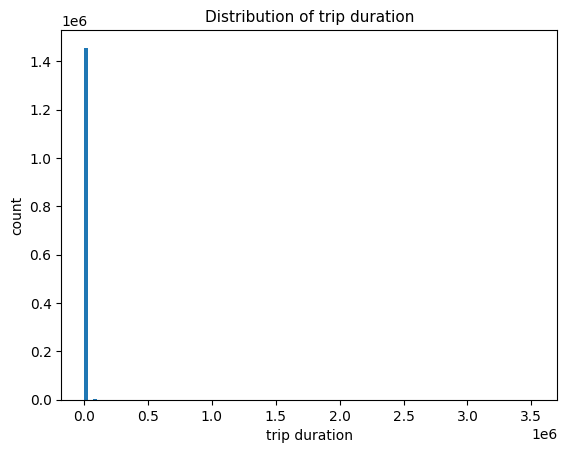

In [ ]:
plt.hist(df['trip_duration'], bins=100)
plt.xlabel('trip duration')
plt.ylabel('count')
plt.title('Distribution of trip duration', fontsize=11);

**Вопрос**: Что можно сказать о целевой переменной по гистограмме её значений?

**Ответ**: Большая часть наблюдений имеет небольшой разброс значений целевой переменной, но есть выбросы с огромными значениями (миллионы секунд).

В соревновании в качестве метрики качества использовалось RMSLE:
$$\text{RMSLE}(X, y, a) = \sqrt{\frac{1}{\ell}\sum_{i=1}^{\ell} \big(\log{(y_i + 1)} - \log{(a(x_i) + 1)}\big)^2}$$

**Вопрос**: Как вы думаете, почему авторы соревнования выбрали именно RMSLE, а не RMSE?

Из-за разброса масштаба целевой переменной, ошибка RMSE может быть большой, если предсказываемый таргет тоже высокий. Чтобы сравнивать не абсолютную ошибку, а относительную (если мы берем логарифмы от предикта и настоящего значения, вычитая из одного другое мы как бы оцениваем отношение данных значений). Тогда, если мы выбираем RMSLE, нам важно насколько хорошо модель предсказывает относительное изменение, а не абсолютные числа.

На семинаре мы рассматривали несколько моделей линейной регрессии в `sklearn`, но каждая из них оптимизировала среднеквадратичную ошибку (MSE), а не RMSLE. Давайте проделаем следующий трюк: будем предсказывать не целевую переменную, а ее *логарифм*. Обозначим $\hat{y}_i = \log{(y_i + 1)}$ — модифицированный таргет, а $\hat{a}(x_i)$ — предсказание модели, которая обучалась на $\hat{y}_i$, то есть логарифм таргета. Чтобы предсказать исходное значение, мы можем просто взять экспоненту от нашего предсказания: $a(x_i) = \exp(\hat{a}(x_i)) - 1$.

**Вопрос**: Покажите, что оптимизация RMSLE для модели $a$ эквивалентна оптимизации MSE для модели $\hat{a}$.

**Доказательство**:

Во-первых, заметим, что все таргеты у нас неотрицательные, поэтому далее рассматриваем только их.

$$\text{MSE} (X, \hat{y}, \hat{a}) = \frac{1}{\ell}\sum_{i=1}^{\ell} \big(\hat{y} - \hat{a}\big)^2$$

$$\text{RMSLE} (X, y, a) = \sqrt{\frac{1}{\ell}\sum_{i=1}^{\ell} \big(\log{(y_i + 1)} - \log{(a(x_i) + 1)}\big)^2} = \sqrt{\frac{1}{\ell}\sum_{i=1}^{\ell} \big(\log{(y_i + 1)} - \log{(\exp(\hat{a}(x_i)) - 1 + 1)}\big)^2} = \sqrt{\frac{1}{\ell}\sum_{i=1}^{\ell} \big(\hat{y} - \hat{a}\big)^2} = \text{RMSE}$$

Задача оптимизации RMSLE сводится к задаче оптимизации RMSE, которая, в свою очередь, эквивалентна задаче оптимизации MSE, так как корень - монотонное преобразование, которое не меняет оптимумы.

Итак, мы смогли свести задачу оптимизации RMSLE к задаче оптимизации MSE, которую мы умеем решать! Кроме того, у логарифмирования таргета есть еще одно полезное свойство. Чтобы его увидеть, добавьте к нашей выборке колонку `log_trip_duration` (воспользуйтесь `np.log1p`) и нарисуйте гистограмму модифицированного таргета по обучающей выборке. Удалите колонку со старым таргетом.

In [ ]:
df['log_trip_duration'] = np.log1p(df['trip_duration'])
df.drop('trip_duration', axis=1, inplace=True)

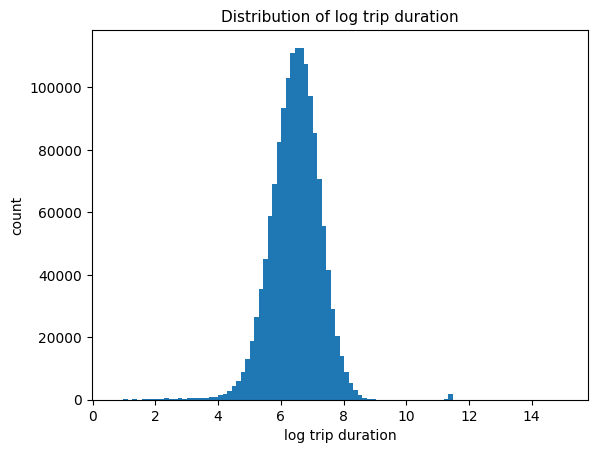

In [ ]:
plt.hist(df['log_trip_duration'], bins=100)
plt.xlabel('log trip duration')
plt.ylabel('count')
plt.title('Distribution of log trip duration', fontsize=11);

Чтобы иметь некоторую точку отсчета, давайте посчитаем значение метрики при наилучшем константном предсказании:

In [ ]:
def rmsle(log1p_y_true, log1p_y_pred):
    rmsle = np.sqrt(np.mean((log1p_y_true - log1p_y_pred) ** 2))
    return rmsle
    raise NotImplementedError

rmsle_best_const = rmsle(df['log_trip_duration'], np.mean(df['log_trip_duration']))
print(rmsle_best_const)
assert np.allclose(rmsle_best_const, 0.79575, 1e-4)

0.7957592365411509


## Часть 1. Изучаем `pickup_datetime` (2 балла)

**Задание 2 (0.25 баллов)**. Для начала давайте посмотрим, сколько всего было поездок в каждый из дней. Постройте график зависимости количества поездок от дня в году:

In [ ]:
count_trip = df.groupby(df['pickup_datetime'].dt.date)['id'].count().reset_index()
count_trip['pickup_datetime'] = pd.to_datetime(count_trip['pickup_datetime'])

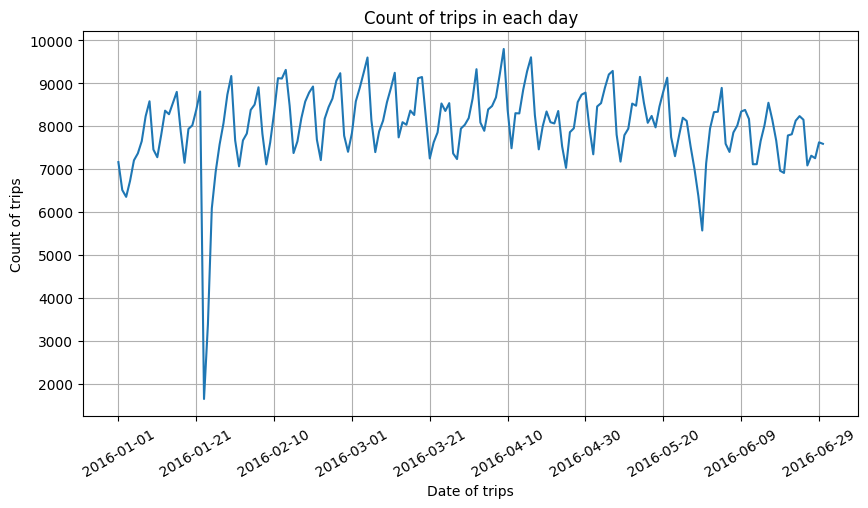

In [ ]:
fig = plt.figure(figsize=(10, 5))
sns.lineplot(data=count_trip, x='pickup_datetime', y='id')
plt.xticks(count_trip.iloc[::20]['pickup_datetime'].values, rotation=30)
plt.xlabel('Date of trips')
plt.ylabel('Count of trips')
plt.title('Count of trips in each day')
plt.grid();

In [ ]:
count_trip[count_trip['id'] < 6000]

,pickup_datetime,id
22,2016-01-23,1648
23,2016-01-24,3383
150,2016-05-30,5570


In [ ]:
count_trip.iloc[21:25]

,pickup_datetime,id
21,2016-01-22,8805
22,2016-01-23,1648
23,2016-01-24,3383
24,2016-01-25,6084


23 января 2016 в года 14:30 из-за снежной бури в Нью-Йорке запретили автомобильное движение, запрет продлился до утра 24 января, поэтому так упало количество перевозок такси.

In [ ]:
count_trip.iloc[148:153]

,pickup_datetime,id
148,2016-05-28,7004
149,2016-05-29,6372
150,2016-05-30,5570
151,2016-05-31,7131
152,2016-06-01,7943


Я не нашла никаких необычных новостей, которые могут объяснить спад вызова такси. 30 мая 2016 года был День поминоваения в США, я нашла, что в Нью-Йорке проводят парад в честь этого дня, возможно, перекрывались дороги, поэтому так мало такси. Может быть, это особенность праздника, когда люди меньше куда-то выходят, ездят (плюс это праздничный выходной)

**Вопрос**: Вы, вероятно, заметили, что на графике есть 2 периода с аномально маленькими количествами поездок. Вычислите, в какие даты происходили эти скачки вниз и найдите информацию о том, что происходило в эти дни в Нью-Йорке.

Нарисуйте графики зависимости количества поездок от дня недели и от часов в сутках:

In [ ]:
count_weekday = df.groupby(df['pickup_datetime'].dt.day_name())['id'].count().reset_index()
count_hours = df.groupby(df['pickup_datetime'].dt.hour)['id'].count().reset_index()

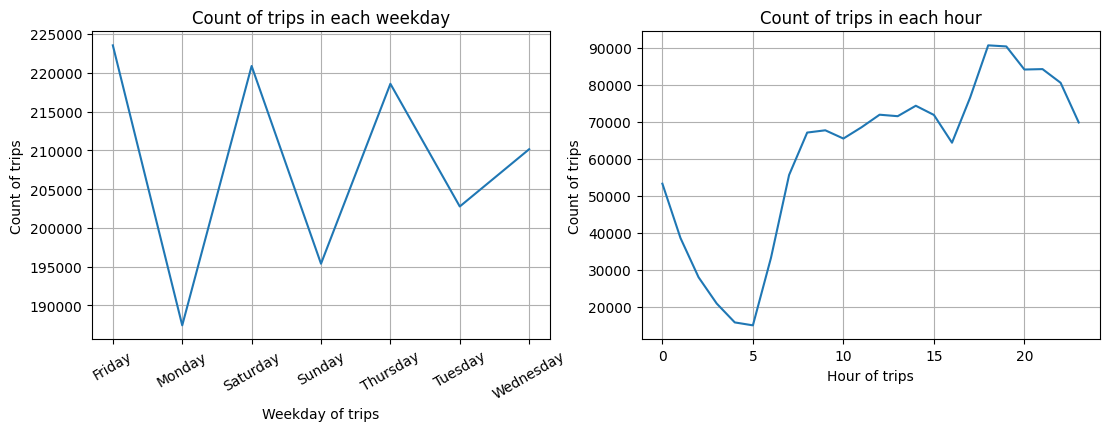

In [ ]:
fig, axs = plt.subplots(figsize=(13, 4), ncols=2)
sns.lineplot(data=count_weekday, x='pickup_datetime', y='id', ax=axs[0])
axs[0].set_xlabel('Weekday of trips')
axs[0].tick_params(axis='x', labelrotation=30)
axs[0].set_ylabel('Count of trips')
axs[0].set_title('Count of trips in each weekday')
axs[0].grid()

sns.lineplot(data=count_hours, x='pickup_datetime', y='id', ax=axs[1])
axs[1].set_xlabel('Hour of trips')
axs[1].set_ylabel('Count of trips')
axs[1].set_title('Count of trips in each hour')
axs[1].grid();

**Задание 3 (0.5 баллов)**. Нарисуйте на одном графике зависимости количества поездок от часа в сутках для разных месяцев (разные кривые, соответствующие разным месяцам, окрашивайте в разные цвета, поищите, как это делается). Аналогично нарисуйте зависимости количества поездок от часа в сутках для разных дней недели.

In [ ]:
df['pickup_month'] = df['pickup_datetime'].dt.month_name()
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_weekday'] = df['pickup_datetime'].dt.day_name()

In [ ]:
count_month_hour = df.groupby([df['pickup_month'], df['pickup_hour']], as_index=False)['id'].count()

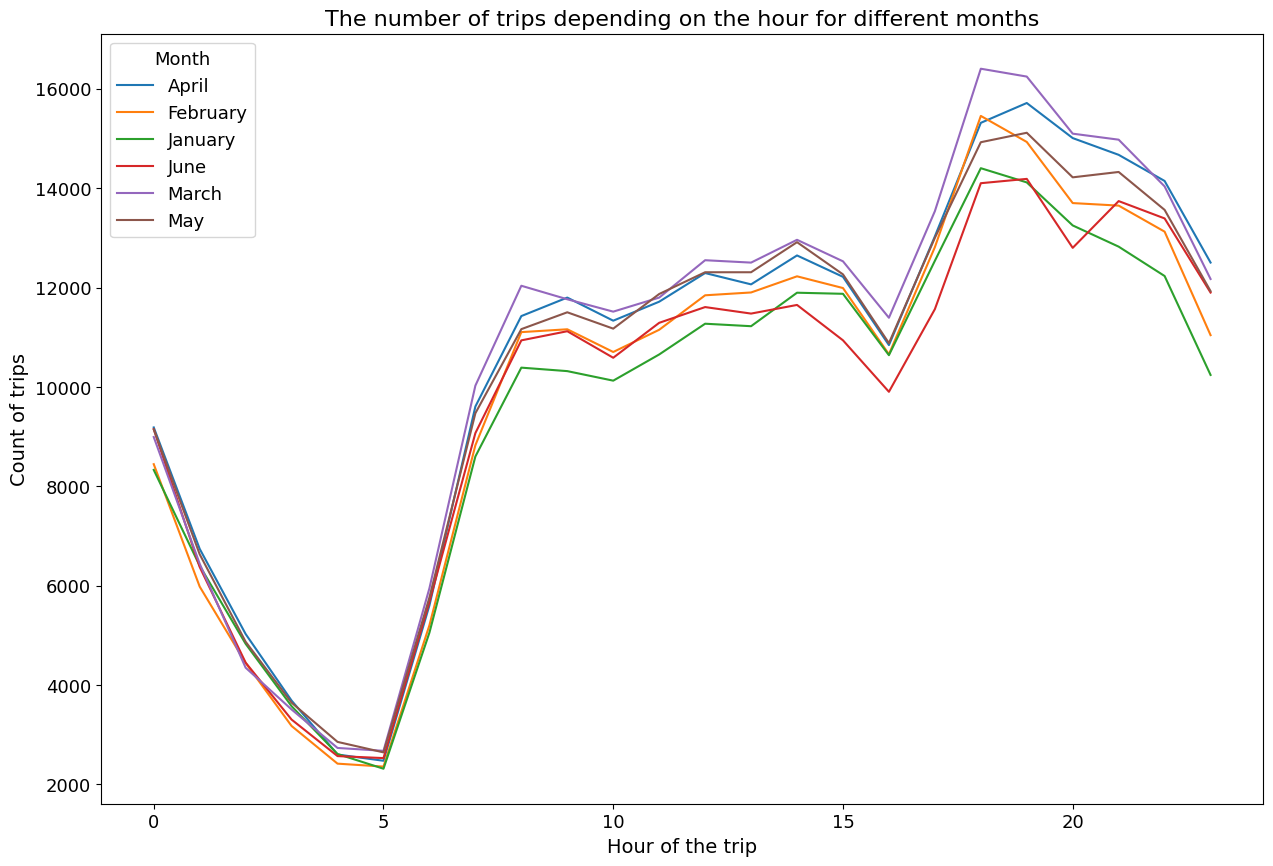

In [ ]:
fig = plt.figure(figsize=(15, 10))
sns.lineplot(data=count_month_hour, x='pickup_hour', y='id', hue='pickup_month')
plt.legend(title='Month', fontsize=13, title_fontsize=13)
plt.title('The number of trips depending on the hour for different months', fontsize=16)
plt.xlabel('Hour of the trip', fontsize=14)
plt.ylabel('Count of trips', fontsize=14)
plt.tick_params(labelsize=13);

In [ ]:
count_weekday_hour = df.groupby([df['pickup_weekday'], df['pickup_hour']], as_index=False)['id'].count()

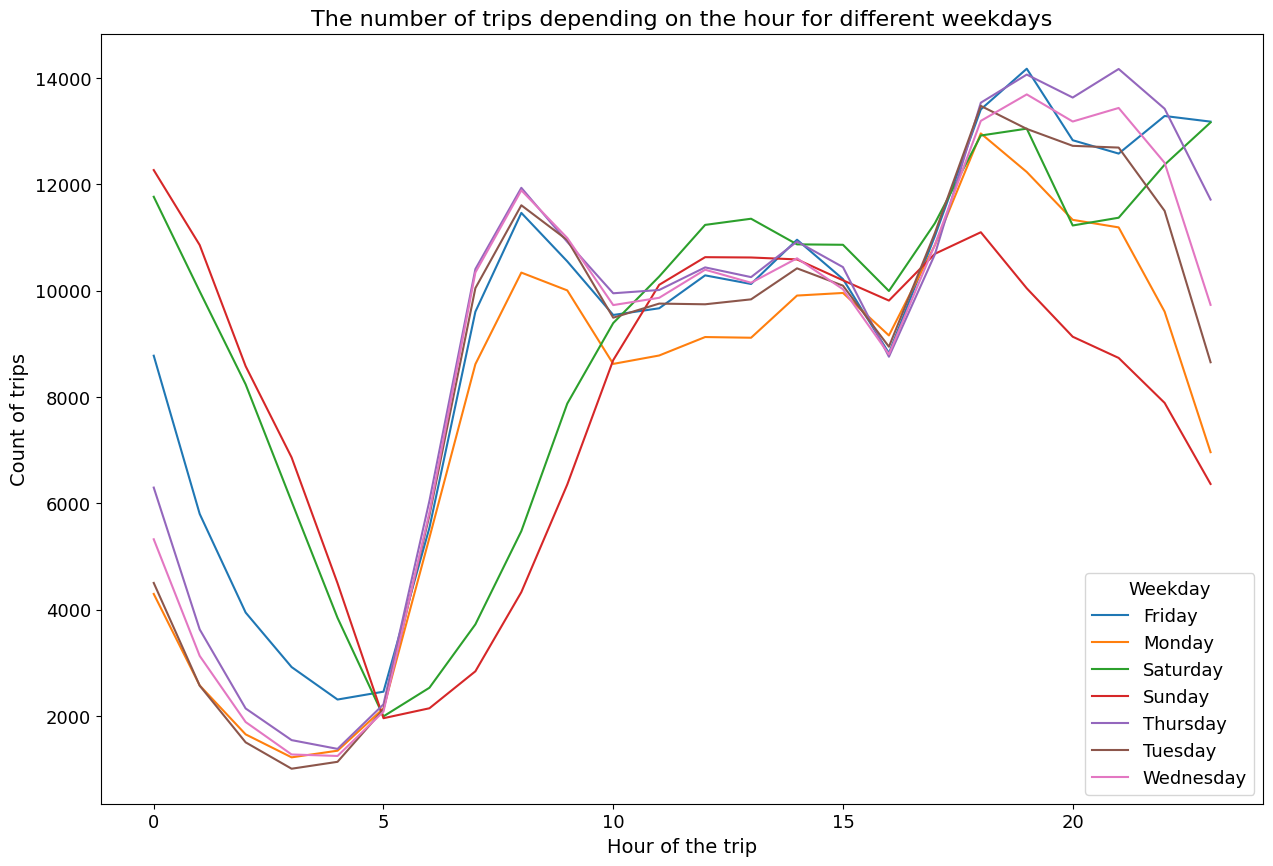

In [ ]:
fig = plt.figure(figsize=(15, 10))
sns.lineplot(data=count_weekday_hour, x='pickup_hour', y='id', hue='pickup_weekday')
plt.legend(title='Weekday', fontsize=13, title_fontsize=13)
plt.title('The number of trips depending on the hour for different weekdays', fontsize=16)
plt.xlabel('Hour of the trip', fontsize=14)
plt.ylabel('Count of trips', fontsize=14)
plt.tick_params(labelsize=13);

**Вопрос**: Какие выводы можно сделать, основываясь на графиках выше? Выделяются ли какие-нибудь дни недели? Месяца? Время суток? С чем это связано?

**Ответ**: Дни недели: пики количества поездок наблюдаются в пятницу, субботу. В пятницу и субботу скорее всего все ездят отдыхать, и предпочитают такси, чем самим садиться за руль. В воскресенье, возможно, многие предпочитают проводить время дома. В будни дни разное количество поездок, возможно, специфика данных.

Время суток: в ночное время (3-5 ночи) количество поездок минимально, затем, к началу рабочего времени оно поднимается, в течение дня держится плюс минус на одном уровне (разное начало рабочего дня + другие дела, не связанные с работой), к концу рабочего дня достигается пик (18-20 часов), затем идет на спад.

Месяцы: март и апрель, судя по графику, имеют чуть больше поездок, что может быть связано с сезонной активностью или увеличением поездок в весенние месяцы.

Количество поездок в зависимости от времени суток в каждый месяц имеет примерно одинаковую динамику, в каждый день недели тоже, но в выходные график сдвигается чуть правее (режим дня меняется с жаворонка на сову :)))

**Задание 4 (0.5 баллов)**. Разбейте выборку на обучающую и тестовую в отношении 7:3 (используйте `train_test_split` из `sklearn`). По обучающей выборке нарисуйте график зависимости среднего логарифма времени поездки от дня недели. Затем сделайте то же самое, но для часа в сутках и дня в году.

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(['log_trip_duration'], axis=1)
y = df['log_trip_duration']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
df_train = pd.concat([X_train, y_train], axis=1)

In [ ]:
mean_trip_weekday = df_train.groupby('pickup_weekday', as_index=False)['log_trip_duration'].mean()

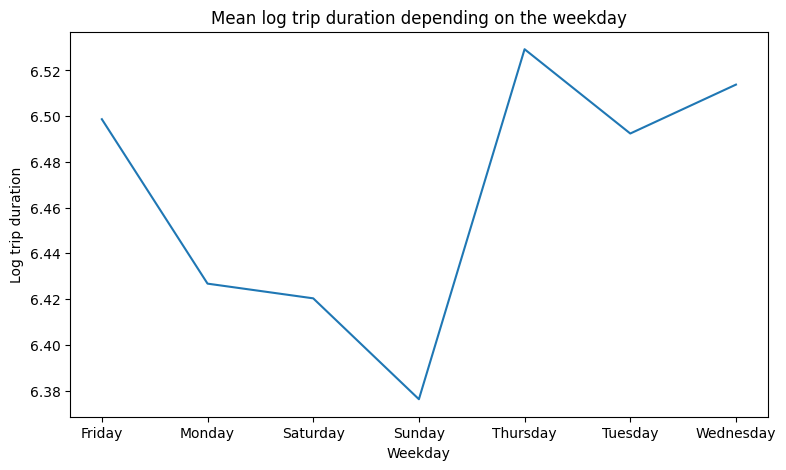

In [ ]:
fig = plt.figure(figsize=(9, 5))
sns.lineplot(data=mean_trip_weekday, x='pickup_weekday', y='log_trip_duration')
plt.title('Mean log trip duration depending on the weekday', fontsize=12)
plt.xlabel('Weekday', fontsize=10)
plt.ylabel('Log trip duration', fontsize=10);

In [ ]:
mean_trip_hour = df_train.groupby('pickup_hour', as_index=False)['log_trip_duration'].mean()

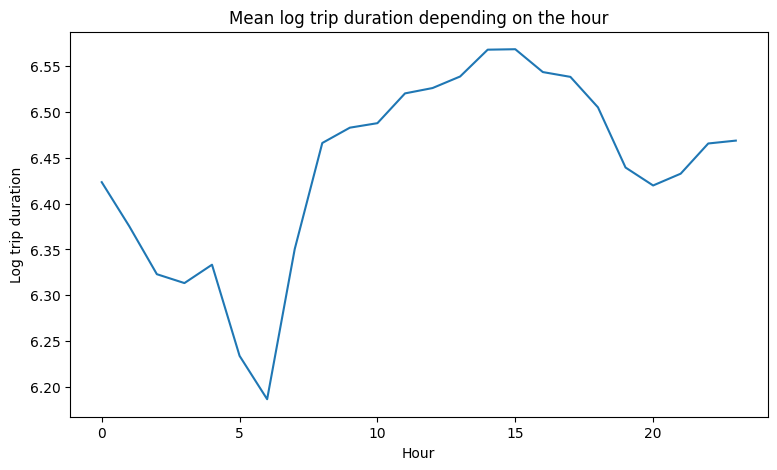

In [ ]:
fig = plt.figure(figsize=(9, 5))
sns.lineplot(data=mean_trip_hour, x='pickup_hour', y='log_trip_duration')
plt.title('Mean log trip duration depending on the hour', fontsize=12)
plt.xlabel('Hour', fontsize=10)
plt.ylabel('Log trip duration', fontsize=10);

In [ ]:
df_train['pickup_dayofyear'] = df_train['pickup_datetime'].dt.dayofyear
X_train['pickup_dayofyear'] = X_train['pickup_datetime'].dt.dayofyear

In [ ]:
mean_trip_day = df_train.groupby('pickup_dayofyear', as_index=False)['log_trip_duration'].mean()

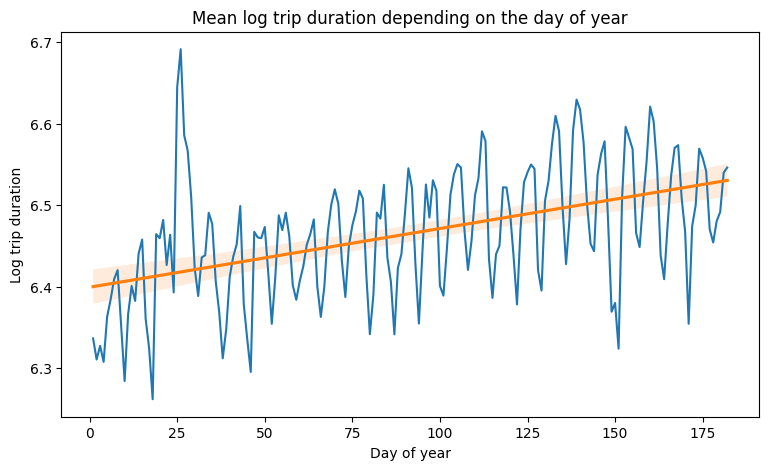

In [ ]:
fig = plt.figure(figsize=(9, 5))
sns.lineplot(data=mean_trip_day, x='pickup_dayofyear', y='log_trip_duration')
sns.regplot(data=mean_trip_day, x='pickup_dayofyear', y='log_trip_duration', scatter=False)
plt.title('Mean log trip duration depending on the day of year', fontsize=12)
plt.xlabel('Day of year', fontsize=10)
plt.ylabel('Log trip duration', fontsize=10);

**Вопрос**: Похожи ли графики зависимости таргета от дня недели и от часа в сутках на аналогичные графики для количества поездок? Почему? Что происходит со средним таргетом в те два аномальных периода, что мы видели выше? Почему так происходит? Наблюдаете ли вы какой-нибудь тренд на графике зависимости `log_trip_duration` от номера дня в году?

**Ответ**: графики зависимости таргета от дня недели и от часа в сутках на аналогичные графики для количества поездок показывают примерно такую же динамику (за исключением субботы), так как высокое количество поездок происходит в часы пик, ухудшается ситуация на дорогах, образуются пробки, поэтому и время в пути тоже увеличивается.

В аномальные периоды со средним таргетом, если судить по графику ничего необычного не происходит, только у второй аномалии (30 мая) он снизился до уровня ниже соседних. В период метели в принципе было запрещено автомобильное движение, виден скачок уже после снятия ограничений (возможно, еще не успели убрать последствия бури). 30 мая, если аномалия произошла из-за праздника, то люди, скорее всего, сидели по большей части дома или просто меньше пользовались транспортом, поэтому время в пути снизилось.

Добавьте следующие признаки на основе `pickup_datetime`:
1. День недели
2. Месяц
3. Час
4. Является ли период аномальным (два бинарных признака, соответствующие двум аномальным периодам)
5. Номер дня в году

In [ ]:
anomaly_dates = [pd.to_datetime('2016-01-23').date(), pd.to_datetime('2016-01-24').date(), pd.to_datetime('2016-05-30').date()]

In [ ]:
X_train['anomaly'] = X_train['pickup_datetime'].dt.date.isin(anomaly_dates) * 1

In [ ]:
X_test['pickup_dayofyear'] = X_test['pickup_datetime'].dt.dayofyear
X_test['anomaly'] = X_test['pickup_datetime'].dt.date.isin(anomaly_dates) * 1

In [ ]:
X_train

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_month,pickup_hour,pickup_weekday,pickup_dayofyear,anomaly
1011257,id2209155,2,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,N,May,9,Tuesday,124,0
178550,id0586605,1,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,N,January,16,Friday,1,0
551460,id0467144,1,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,N,April,13,Sunday,115,0
1434271,id0989010,2,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,N,January,17,Sunday,10,0
1173610,id0580742,1,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,N,February,17,Thursday,56,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,id1753868,2,2016-03-25 07:11:49,2,-73.955032,40.777328,-74.006203,40.749424,N,March,7,Friday,85,0
1414414,id2204747,1,2016-02-16 18:01:45,1,-73.973618,40.763920,-73.983849,40.749874,N,February,18,Tuesday,47,0
131932,id3043606,2,2016-01-26 19:22:29,1,-74.006195,40.734283,-73.949608,40.785282,N,January,19,Tuesday,26,0
671155,id1458584,1,2016-01-19 11:53:47,1,-73.962341,40.767323,-73.969757,40.768669,N,January,11,Tuesday,19,0


Итак, мы уже создали некоторое количество признаков.

**Вопрос**: Какие из признаков _стоит рассматривать в этой задаче_   как категориальные, а какие - как численные? Почему?

**Ответ**: Количественные: широта и долгота точек начала и конца поездки, дата, количество пассажиров, потому что мы можем по числовой характеристике данного признака сравнить один объект с другим, посчитать расстояние и тд.

Качественные - все остальные, так как они определяют лишь категорию, к которой относится наблюдение, нельзя их сравнить по числовой (если признак определяется числом, например, день в году) характеристике или по названию (мы не можем сказать, что id 11222 лучше, чем id 1111; что 55 день в году хуже, чем 67, не можем посчитать насколько лучше и тд).

**Задание 5 (0.75 баллов)**. Обучите `Ridge`-регрессию с параметрами по умолчанию, закодировав все категориальные признаки с помощью `OneHotEncoder`. Численные признаки отмасштабируйте с помощью `StandardScaler`. Используйте только признаки, которые мы выделили в этой части задания.

In [ ]:
cat = ['pickup_month', 'pickup_weekday', 'anomaly', 'pickup_hour', 'pickup_dayofyear']

In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', drop='if_binary')
ohe.fit(X_train[cat])
X_train_cat = pd.DataFrame(ohe.transform(X_train[cat]).toarray(), columns=ohe.get_feature_names_out())
X_test_cat = pd.DataFrame(ohe.transform(X_test[cat]).toarray(), columns=ohe.get_feature_names_out())

In [ ]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_cat, y_train)
y_train_pred = ridge.predict(X_train_cat)
y_test_pred = ridge.predict(X_test_cat)
print(f'RMSLE on train: {rmsle(y_train, y_train_pred)}')
print(f'RMSLE on test: {rmsle(y_test, y_test_pred)}')

RMSLE on train: 0.7879583678092381
RMSLE on test: 0.7871298530021767


## Часть 2. Изучаем координаты (3 балла)
Мы уже очень хорошо изучили данные о времени начала поездки, давайте теперь посмотрим на информацию о координатах начала и конца поездки. Мы подготовили для вас функцию, которая на карте рисует точки начала или конца поездки. Примеры ее вызова вы найдете ниже. Обратите внимание, что в эту функцию мы передаем лишь небольшой кусочек данных, посколько иначе функция будет работать очень долго

In [ ]:
from typing import Iterable

def show_circles_on_map(
    latitude_values: Iterable[float],
    longitude_values: Iterable[float],
    color: str = "blue",
) -> folium.Map:
    """
    The function draws map with circles on it.
    The center of the map is the mean of coordinates passed in data.
    Works best on samples of size < 10k, too costly otherwise

    latitude_values: sample latitude values of a dataframe
    longitude_column: sample longitude values of a dataframe
    color: the color of circles to be drawn
    """

    location = (np.mean(latitude_values), np.mean(longitude_values))
    m = folium.Map(location=location)

    for lat, lon in zip(latitude_values, longitude_values):
        folium.Circle(
            radius=100,
            location=(lat, lon),
            color=color,
            fill_color=color,
            fill=True
        ).add_to(m)

    return m

Напишите функция, которая вернет значения колонок `pickup_latitude`, `pickup_longitude` на каком-нибудь разумном кусочке датафрейма, например, `df.sample(1000)` и покажите на карте, используя `show_circles_on_map`

In [ ]:
np.random.seed(66)
your_lat_values = df.sample(1000)['pickup_latitude'].values
your_lon_values = df.sample(1000)['pickup_longitude'].values

show_circles_on_map(your_lat_values, your_lon_values, color="midnightblue")

**Вопрос**: Какие пункты (или скопления точек, в количестве 2-3), по вашему мнению, выделяются на карте от основной массы и могут быть полезны для нашей задачи? Почему вы их выбрали? В чём особенность этих скоплений точек для нашей задачи?

**Ответ**: 1 пункт - аэропорт Джона Кеннеди, 2 пункт - Rikers Island, 3 пункт - аэропорт LaGuardia. Первый и второй интересны, тк скорее всего около аэропортов большие пробки + может не быть свободных парковочных мест, поэтому время поездки может увеличиться. Второй соединен с городом только одним мостом, и в часы пик там может быть более плотная загрузка на дороге.

**Задание 6 (0.75 балл)**. Как мы все прекрасно помним, $t = s / v_{\text{ср}}$, поэтому очевидно, что самым сильным признаком будет расстояние, которое необходимо проехать. Мы не можем посчитать точное расстояние, которое необходимо преодолеть такси, но мы можем его оценить, посчитав кратчайшее расстояние между точками начала и конца поездки. Чтобы корректно посчитать расстояние между двумя точками на Земле, можно использовать функцию `haversine`. Также можно воспользоваться кодом с первого семинара. Посчитайте кратчайшее расстояние для объектов и запишите его в колонку `haversine`:

In [ ]:
def haversine_array(lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    AVG_EARTH_RADIUS = 6371
    lat = lat2 - lat1
    lng = lng2 - lng1
    d = np.sin(lat * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng * 0.5) ** 2
    h = 2 * AVG_EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h

In [ ]:
X_train['haversine'] = haversine_array(X_train['pickup_latitude'], X_train['pickup_longitude'], X_train['dropoff_latitude'], X_train['dropoff_longitude'])
X_test['haversine'] = haversine_array(X_test['pickup_latitude'], X_test['pickup_longitude'], X_test['dropoff_latitude'], X_test['dropoff_longitude'])

Так как мы предсказываем логарифм времени поездки и хотим, чтобы наши признаки были линейно зависимы с этой целевой переменной, нам нужно логарифмировать расстояние: $\log t = \log s - \log{v_{\text{ср}}}$. Запишите логарифм `haversine` в отдельную колонку `log_haversine`:

In [ ]:
X_train['log_haversine'] = np.log1p(X_train['haversine'])
X_test['log_haversine'] = np.log1p(X_test['haversine'])

Посчитайте корреляцию и убедитесь, что логарифм расстояния лучше отражает таргет, чем просто расстояние:

In [ ]:
print(f'Корреляция между логарифмом расстояния и таргетом: {np.corrcoef(X_train["log_haversine"], y_train)[0, 1]}')
print(f'Корреляция между обычным расстоянием и таргетом: {np.corrcoef(X_train["haversine"], y_train)[0, 1]}')

Корреляция между логарифмом расстояния и таргетом: 0.7499594955685644
Корреляция между обычным расстоянием и таргетом: 0.5654059873890238


Корреляция с логарифмом выше, значит, он лучше объясняет таргет.

**Задание 7 (0.75 балла)**. Давайте изучим среднюю скорость движения такси. Посчитайте среднюю скорость для каждого объекта обучающей выборки, разделив `haversine` на `trip_duration`, и нарисуйте гистограмму ее распределения

In [ ]:
trip_duration = np.exp(y_train) - 1

In [ ]:
X_train['v_mean'] = X_train['haversine'] / trip_duration

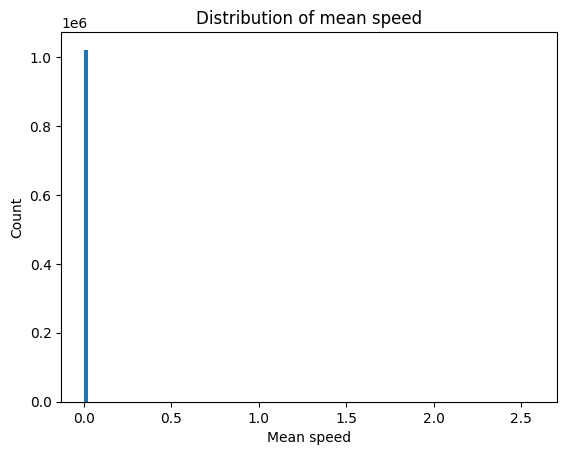

In [ ]:
plt.hist(X_train['v_mean'], bins=100)
plt.xlabel('Mean speed')
plt.ylabel('Count')
plt.title('Distribution of mean speed');

Как можно видеть по гистограмме, для некоторых объектов у нас получились очень больше значения скоростей. Нарисуйте гистограмму по объектам, для которых значение скорости получилось разумным (например, можно не включать рассмотрение объекты, где скорость больше некоторой квантили):

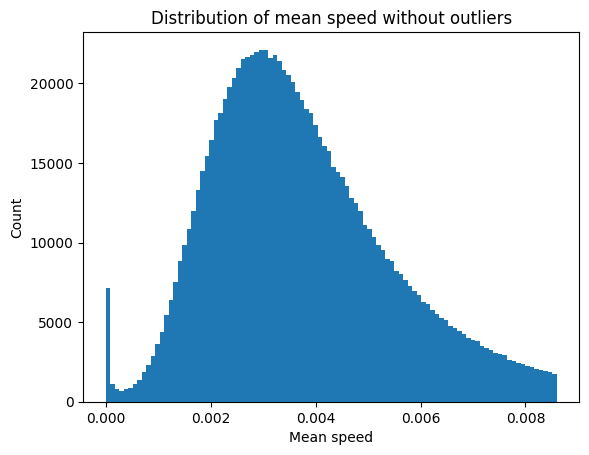

In [ ]:
# использую межквартильный размах
q1 = X_train['v_mean'].quantile(0.25)
q3 = X_train['v_mean'].quantile(0.75)
iqr = q3 - q1
lim = q3 + 1.5 * iqr

plt.hist(X_train.loc[X_train['v_mean'] < lim, 'v_mean'], bins=100)
plt.xlabel('Mean speed')
plt.ylabel('Count')
plt.title('Distribution of mean speed without outliers');

Для каждой пары (день недели, час суток) посчитайте медиану скоростей. Нарисуйте Heatmap-график, где по осям будут дни недели и часы, а в качестве значения функции - медиана скорости

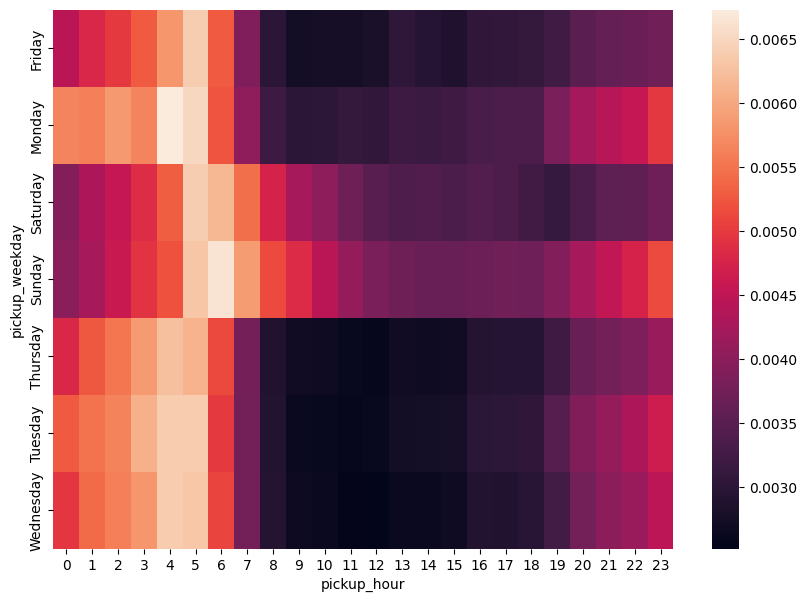

In [ ]:
fig = plt.figure(figsize=(10, 7))
sns.heatmap(pd.pivot_table(X_train, index='pickup_weekday', columns='pickup_hour', values='v_mean', aggfunc='median'))
plt.xticks(rotation=0);

Не забудьте удалить колонку со значением скорости из данных!

**Вопрос**: Почему значение скорости нельзя использовать во время обучения?

**Ответ**: скорость посчитана на основе таргета (trip_duration), который мы не можем знать на тесте, так как мы его предсказываем.

In [ ]:
X_train.drop('v_mean', axis=1, inplace=True)

**Вопрос**: Посмотрите внимательно на график и скажите, в какие моменты времени скорость минимальна; максимальна.

**Ответ**: Минимальна в часы пик (в будни в течение рабочего дня, в пятницу до конца дня, тк это день перед выходными, в субботу немного ночью и днем-вечером, люди едут отдыхать, в воскресенье ночью и немного вечером). Максимальна ночью-ранним утром в будни, утром-днем в выходные (обычно в это время все спят)

Создайте признаки "поездка совершается в период пробок" и "поездка совершается в период свободных дорог" (естественно, они не должен зависеть от скорости!):

In [ ]:
def traffic(X):

    workday1 = ['Monday', 'Tuesday']
    workday2 = ['Wednesday', 'Thursday']

    traf_mon_tue = ((X['pickup_weekday'].isin(workday1)) &
                ((X['pickup_hour'] >= 7) & (X['pickup_hour'] <= 19)))
    traf_wed_thurs = ((X['pickup_weekday'].isin(workday2)) &
                ((X['pickup_hour'] >= 7) & (X['pickup_hour'] <= 21)))
    traf_frid = ((X['pickup_weekday'] == 'Friday') &
                ((X['pickup_hour'] >= 7) & (X['pickup_hour'] <= 23)))
    traf_sat = ((X['pickup_weekday'] == 'Saturday') &
                (((X['pickup_hour'] >= 11) & (X['pickup_hour'] <= 23)) |
                (X['pickup_hour'] == 0)))
    traf_sun = ((X['pickup_weekday'] == 'Sunday') &
                (((X['pickup_hour'] >= 12) & (X['pickup_hour'] <= 18)) |
                (X['pickup_hour'] == 0)))

    return (traf_mon_tue | traf_wed_thurs | traf_frid | traf_sat | traf_sun) * 1


X_train['traffic'] = traffic(X_train)
X_test['traffic'] = traffic(X_test)


In [ ]:
def free_road(X):

    workday1 = ['Monday', 'Tuesday']
    workday2 = ['Wednesday', 'Thursday']
    weekends = ['Saturday', 'Sunday']
    free_mon_tue = ((X['pickup_weekday'].isin(workday1)) &
                    (X['pickup_hour'] < 6))
    free_wed_thurs = ((X['pickup_weekday'].isin(workday2)) &
                ((X['pickup_hour'] < 6) & (X['pickup_hour'] > 0)))
    free_frid = ((X['pickup_weekday'] == 'Friday') &
                ((X['pickup_hour'] >= 3) & (X['pickup_hour'] <= 5)))
    free_sat_sun = ((X['pickup_weekday'].isin(weekends)) &
                ((X['pickup_hour'] >= 5) & (X['pickup_hour'] <= 7)))

    return (free_mon_tue | free_wed_thurs | free_frid | free_sat_sun) * 1

X_train['free_road'] = free_road(X_train)
X_test['free_road'] = free_road(X_test)
gc.collect()

27126

**Задание 8 (0.25 балла)**. Для каждого из замеченных вами выше 2-3 пунктов добавьте в выборку по два признака:
- началась ли поездка в этом пункте
- закончилась ли поездка в этом пункте

Как вы думаете, почему эти признаки могут быть полезны?

**Ответ**: если поездка начинается из этого места или заканчивается там, возможно нужна корректировка времени в пути, так как могут быть пробки по пути к данному / из данного места.



In [ ]:
# аэропорт Джона Кеннеди
airport_lat = 40.639751
airport_long = -73.778926
X_train['is_airport_ken_pickup'] = (haversine_array(X_train['pickup_latitude'], X_train['pickup_longitude'], airport_lat, airport_long) <= 2) * 1
X_train['is_airport_ken_dropoff'] = (haversine_array(X_train['dropoff_latitude'], X_train['dropoff_longitude'], airport_lat, airport_long) <= 2) * 1

X_test['is_airport_ken_pickup'] = (haversine_array(X_test['pickup_latitude'], X_test['pickup_longitude'], airport_lat, airport_long) <= 2) * 1
X_test['is_airport_ken_dropoff'] = (haversine_array(X_test['dropoff_latitude'], X_test['dropoff_longitude'], airport_lat, airport_long) <= 2) * 1

In [ ]:
# остров (оказалось, это тюрьма ://///)
island_lat = 40.7931277
island_long = -73.88601

X_train['is_island_pickup'] = (haversine_array(X_train['pickup_latitude'], X_train['pickup_longitude'], island_lat, island_long) <= 2) * 1
X_train['is_island_dropoff'] = (haversine_array(X_train['dropoff_latitude'], X_train['dropoff_longitude'], island_lat, island_long) <= 2) * 1

X_test['is_island_pickup'] = (haversine_array(X_test['pickup_latitude'], X_test['pickup_longitude'], island_lat, island_long) <= 2) * 1
X_test['is_island_dropoff'] = (haversine_array(X_test['dropoff_latitude'], X_test['dropoff_longitude'], island_lat, island_long) <= 2) * 1

In [ ]:
# аэропорт LaGuardia
airport2_lat = 40.714
airport2_long = -74.006
X_train['is_airport_lag_pickup'] = (haversine_array(X_train['pickup_latitude'], X_train['pickup_longitude'], airport2_lat, airport2_long) <= 2) * 1
X_train['is_airport_lag_dropoff'] = (haversine_array(X_train['dropoff_latitude'], X_train['dropoff_longitude'], airport2_lat, airport2_long) <= 2) * 1

X_test['is_airport_lag_pickup'] = (haversine_array(X_test['pickup_latitude'], X_test['pickup_longitude'], airport2_lat, airport2_long) <= 2) * 1
X_test['is_airport_lag_dropoff'] = (haversine_array(X_test['dropoff_latitude'], X_test['dropoff_longitude'], airport2_lat, airport2_long) <= 2) * 1

Для каждого из созданных признаков нарисуйте "ящик с усами" (aka boxplot) распределения логарифма времени поездки

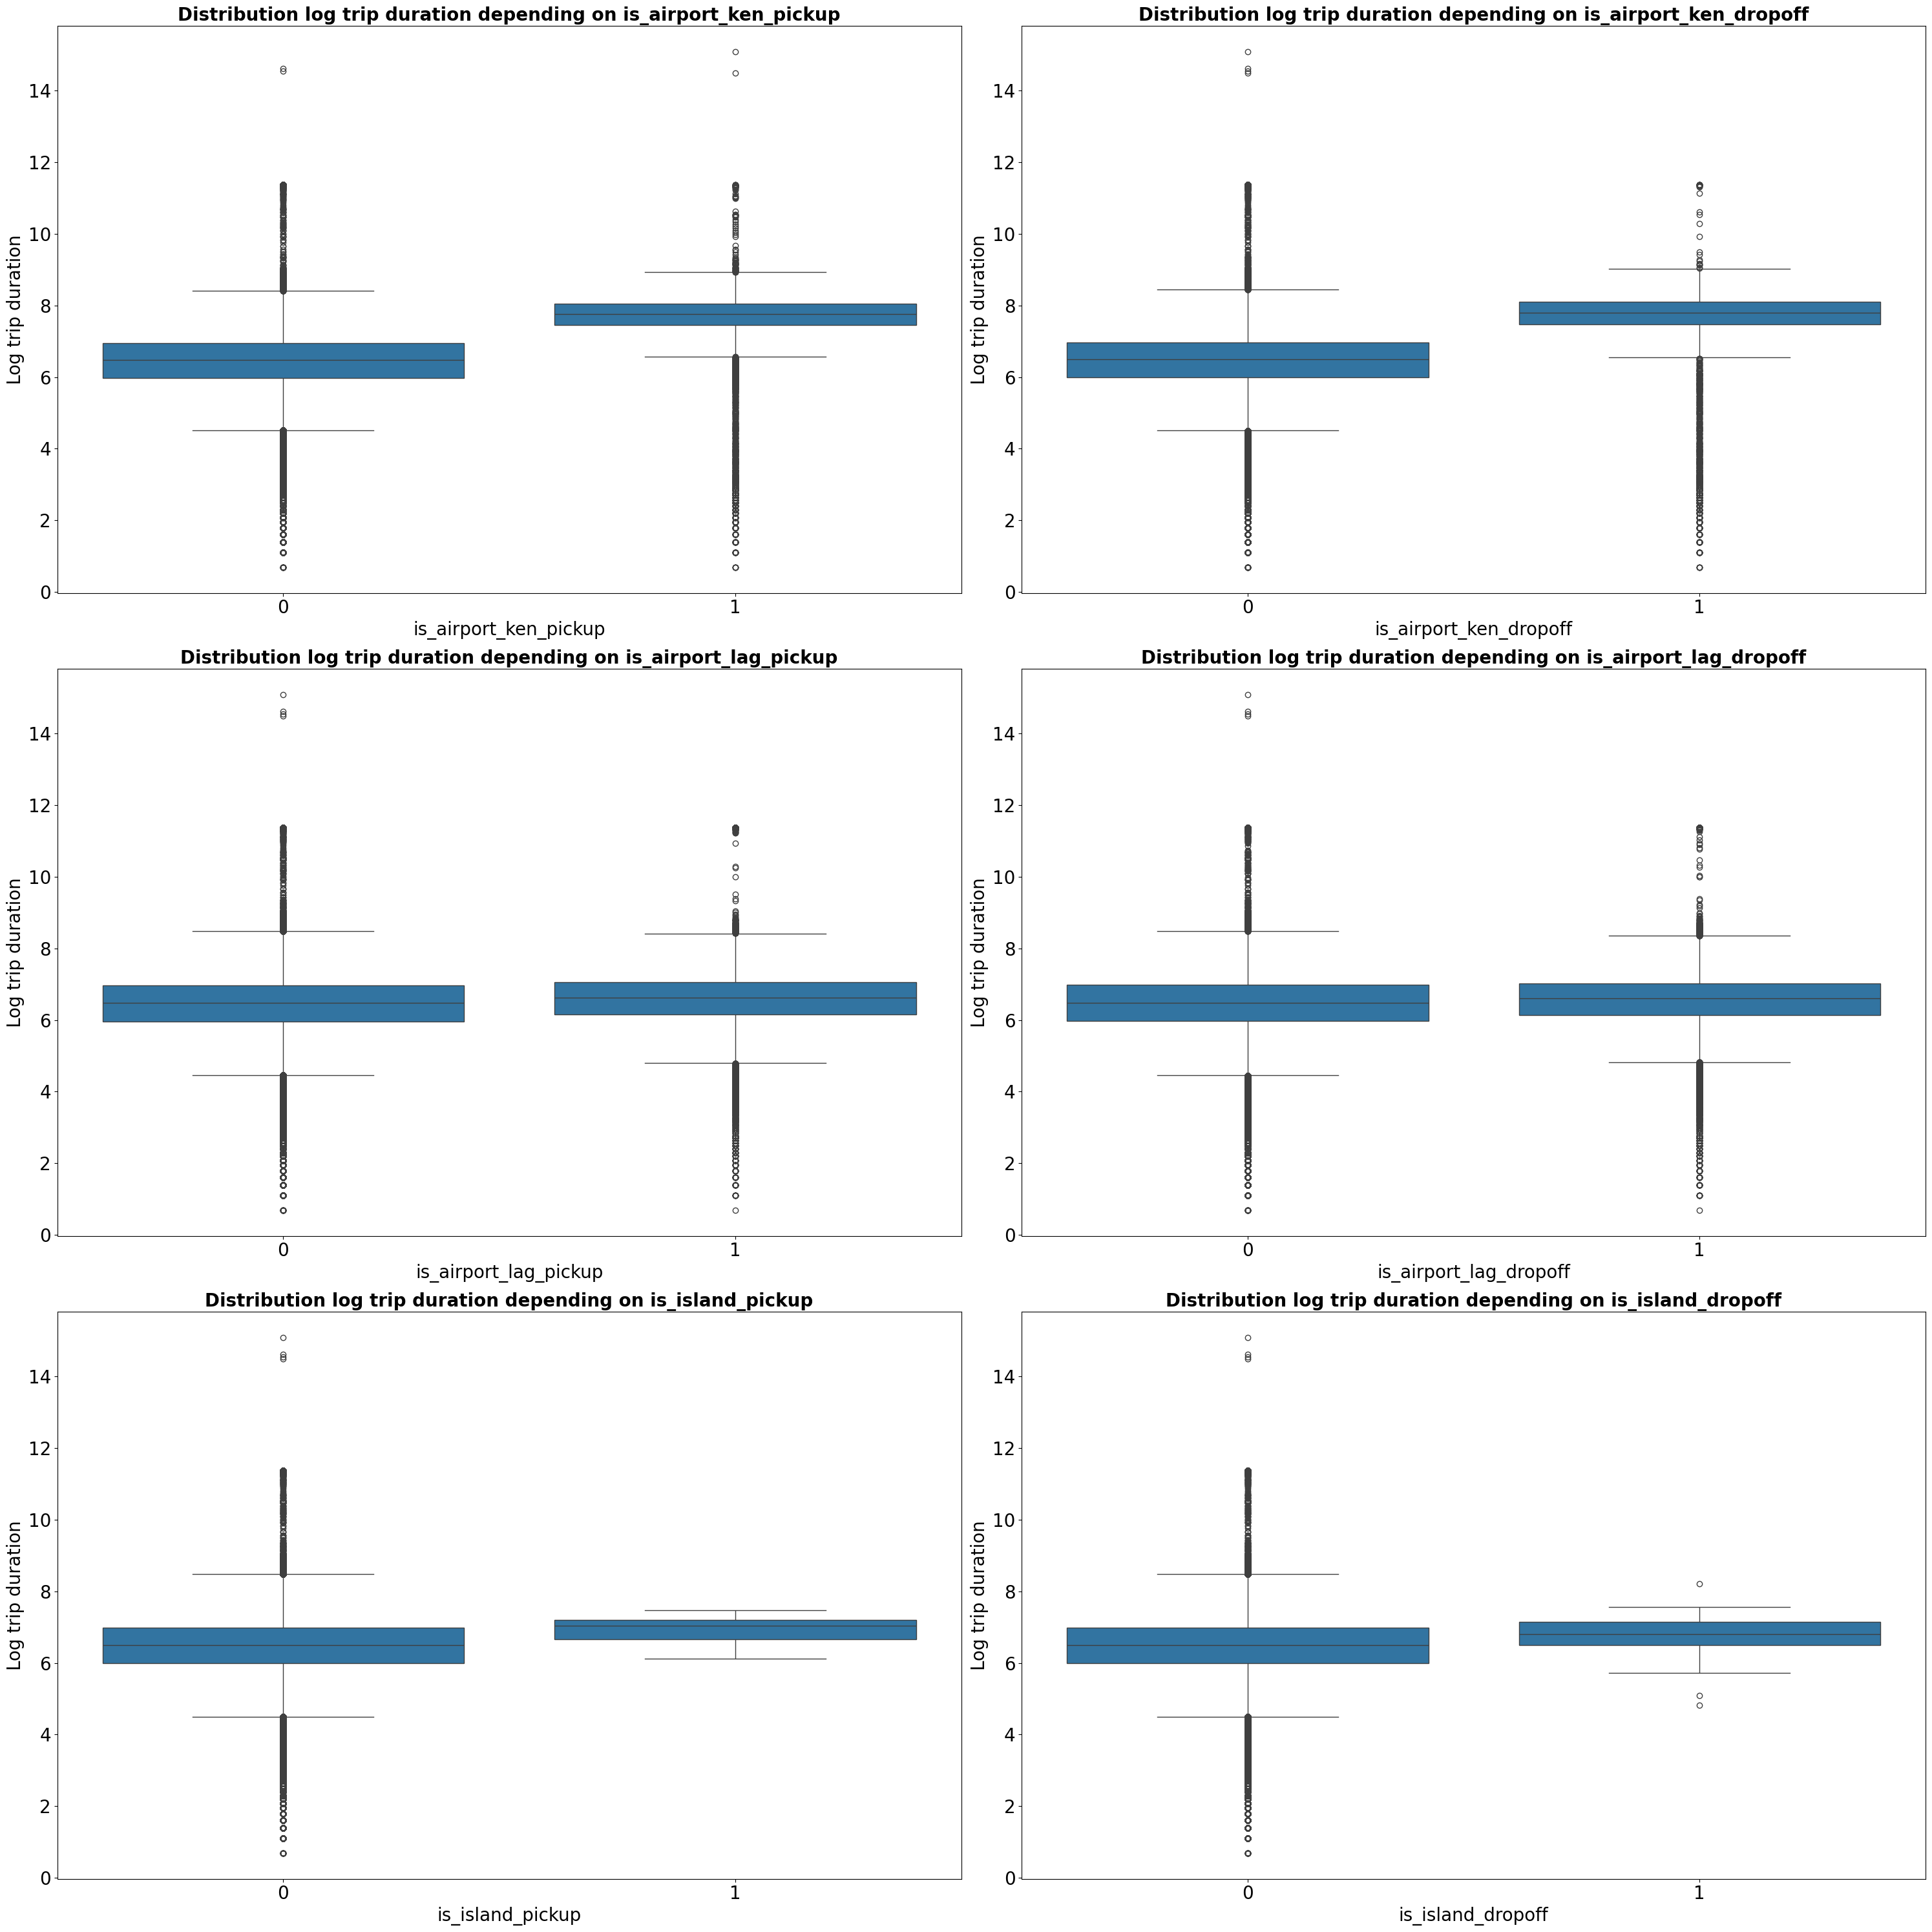

In [ ]:
from matplotlib import gridspec
import itertools

fig = plt.figure(figsize = (30, 30))
gr = gridspec.GridSpec(3, 2)
features = ['is_airport_ken_pickup', 'is_airport_ken_dropoff', 'is_airport_lag_pickup', 'is_airport_lag_dropoff', 'is_island_pickup', 'is_island_dropoff']
for feature, grd in zip(features, itertools.product([0, 1, 2], [0, 1])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.boxplot(data=pd.concat([X_train, y_train], axis=1), x=feature, y='log_trip_duration')
    ax.tick_params(labelsize=20)
    ax.set_title(f'Distribution log trip duration depending on {feature}', fontsize = 20, fontweight='heavy')
    ax.set_xlabel(feature, fontsize = 20)
    ax.set_ylabel('Log trip duration', fontsize = 20)
fig.tight_layout()
plt.show()

**Вопрос**: судя по графикам, как вы думаете, хорошими ли получились эти признаки?

**Ответ**: признак, связанный с аэропортом Джона Кеннеди получился хорошим, так как в общей массе время в пути для тех поездок, которые начинаются/заканчиваются там, больше. Второй аэропорт кажется не очень хорошим признаком, тк время в пути примерно одинаковое. Остров разберу далее.


In [ ]:
X_train['is_island_dropoff'].value_counts()

,count
is_island_dropoff,
0,1021017
1,33


In [ ]:
X_train['is_island_pickup'].value_counts()

,count
is_island_pickup,
0,1021044
1,6


Как выяснилось, этот остров - тюрьма (я изначально подумала, что просто остров, где находятся жилые кварталы), поэтому вряд ли будут сильные заторы на дорогах по пути к тюрьме или от нее (это же показывает боксплот). Плюс поездок, которые начинаются/ заканчиваются там очень мало, было решено выкинуть этот признак из наблюдений.

In [ ]:
X_train.drop(['is_island_pickup', 'is_island_dropoff'], axis=1, inplace=True)

In [ ]:
X_test.drop(['is_island_pickup', 'is_island_dropoff'], axis=1, inplace=True)

<img src="https://www.dropbox.com/s/xson9nukz5hba7c/map.png?raw=1" align="right" width="20%" style="margin-left: 20px; margin-bottom: 20px">

**Задание 9 (1 балл)**. Сейчас мы почти что не используем сами значения координат. На это есть несколько причин: по отдельности рассматривать широту и долготу не имеет особого смысла, стоит рассматривать их вместе. Во-вторых, понятно, что зависимость между нашим таргетом и координатами не линейная. Чтобы как-то использовать координаты, можно прибегнуть к следующему трюку: обрамим область с наибольшим количеством поездок прямоугольником (как на рисунке). Разобьем этот прямоугольник на ячейки. Каждой точке сопоставим номер ее ячейки, а тем точкам, что не попали ни в одну из ячеек, сопоставим значение -1.

Напишите трансформер, который сначала разбивает показанную на рисунке область на ячейки, а затем создает два признака: номер ячейки, в которой началась поездка, и номер ячейки, в которой закончилась поездка. Количество строк и столбцов выберите самостоятельно.

Обратите внимание, что все вычисления должны быть векторизованными, трансформер не должен модифицировать передаваемую ему выборку inplace, а все необходимые статистики (если они вдруг нужны) нужно считать только по обучающей выборке в методе `fit`:

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin


# TransformerMixin implements fit_transform for you,
# applying your fit and transform consistently

class MapGridTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, coord, ncol, nrow, colnames):
        self.coord = coord
        self.ncol = ncol
        self.nrow = nrow
        self.colnames = colnames
        self.pickup_lat = colnames[0]
        self.pickup_long = colnames[1]
        self.dropoff_lat = colnames[2]
        self.dropoff_long = colnames[3]
        self.cell_lat = None
        self.cell_long = None
        pass


    def show_map(self):
        return show_circles_on_map(self.cell_lat, self.cell_long)


    def fit(self, X=None, y=None):
        self.cell_lat = np.linspace(self.coord[:, 0].min(), self.coord[:, 0].max(), self.nrow + 1)
        self.cell_long = np.linspace(self.coord[:, 1].min(), self.coord[:, 1].max(), self.ncol + 1)

        return self.cell_lat, self.cell_long

    def transform(self, X, y=None):
        X_transformed = X.copy()
        pickup_lat_index = np.digitize(X_transformed[self.pickup_lat], self.cell_lat)
        pickup_long_index = np.digitize(X_transformed[self.pickup_long], self.cell_long)
        pickup_index = (pickup_lat_index - 1) * self.ncol + pickup_long_index

        dropoff_lat_index = np.digitize(X_transformed[self.dropoff_lat], self.cell_lat)
        dropoff_long_index = np.digitize(X_transformed[self.dropoff_long], self.cell_long)
        dropoff_index = (dropoff_lat_index - 1) * self.ncol + dropoff_long_index

        not_in_cells_pickup = ((pickup_lat_index == 0) |
                        (pickup_lat_index > self.nrow) |
                        (pickup_long_index == 0) |
                        (pickup_long_index > self.ncol))
        X_transformed['pickup_index'] = not_in_cells_pickup * -1 + ~not_in_cells_pickup * pickup_index

        not_in_cells_dropoff = ((dropoff_lat_index == 0) |
                        (dropoff_lat_index > self.nrow) |
                        (dropoff_long_index == 0) |
                        (dropoff_long_index > self.ncol))

        X_transformed['dropoff_index'] = not_in_cells_dropoff * -1 + ~not_in_cells_dropoff * dropoff_index
        return X_transformed

In [ ]:
coord = np.array([[40.7949032254821,-74.01771634072342],
                  [40.704412636682456,-73.93972437223317],
                  [40.7949032254821, -73.93972437223317],
                  [40.704412636682456, -74.01771634072342]])
col_names = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']
mgt = MapGridTransformer(coord, 3, 4, col_names)
mgt.fit()
X_train = mgt.transform(X_train)
X_test = mgt.transform(X_test)
gc.collect()

7902

**Задание 10 (0.25 балла)**. Обучите `Ridge`-регрессию со стандартными параметрами на признаках, которые мы выделили к текущему моменту. Категориальные признаки закодируйте через one-hot-кодирование, числовые признаки отмасштабируйте.

In [ ]:
categorical = ['pickup_index', 'dropoff_index']
numeric = ['log_haversine']

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('scaling', StandardScaler(), numeric)
], verbose_feature_names_out=False)

column_transformer.fit(X_train)
X_train_ohe_scaler = pd.DataFrame(column_transformer.transform(X_train).toarray(), columns=column_transformer.get_feature_names_out())
X_test_ohe_scaler = pd.DataFrame(column_transformer.transform(X_test).toarray(), columns=column_transformer.get_feature_names_out())
gc.collect()

54

In [ ]:
X_train_prep = pd.concat([X_train_cat, X_train_ohe_scaler, X_train.iloc[:, 16:-2].reset_index(drop=True)], axis=1)
X_test_prep = pd.concat([X_test_cat, X_test_ohe_scaler, X_test.iloc[:, 16:-2].reset_index(drop=True)], axis=1)
gc.collect()

0

In [ ]:
ridge = Ridge()
ridge.fit(X_train_prep, y_train)
y_train_pred = ridge.predict(X_train_prep)
y_test_pred = ridge.predict(X_test_prep)
print(f'RMSLE on train: {rmsle(y_train, y_train_pred)}')
print(f'RMSLE on test: {rmsle(y_test, y_test_pred)}')
gc.collect()

RMSLE on train: 0.4733182642407135
RMSLE on test: 0.4726897765141654


0

Качество регрессии стало сильно лучше!

## Часть 3. Изучаем оставшиеся признаки (1 балл)

**Задание 11 (0.75 баллов)**. У нас осталось еще 3 признака, которые мы не исследовали: `vendor_id`, `passenger_count` и `store_and_fwd_flag`.

**Вопрос**: Подумайте, почему каждый из этих признаков может быть потенциально полезным.

**Ответ**: vendor_id: возможно у разных поставщиков услуг разные условия (транспортное средство, предоставляемые услуги), которые влияют на время в пути. passenger_count: возможно большее количество остановок (чтобы забрать или высадить кого-то по пути), из-за чего время увеличивается. store_and_fwd_flag: если у автомобиля не было подключения к серверу, поездка могла совершаться в местах, где слабый сигнал (например, туннели), где могут быть более сложные дорожные условия.

Посчитайте, сколько есть уникальных значений у каждого из этих признаков:

In [ ]:
X_train['vendor_id'].value_counts()

,count
vendor_id,
2,546566
1,474484


In [ ]:
X_train['passenger_count'].value_counts()

,count
passenger_count,
1,723614
2,147429
5,54532
3,41919
6,33707
4,19804
0,41
7,2
8,1


In [ ]:
X_train['store_and_fwd_flag'].value_counts()

,count
store_and_fwd_flag,
N,1015403
Y,5647


Постройте "ящики с усами" распределений логарифма времени поездки в зависимости от значений каждого из признаков

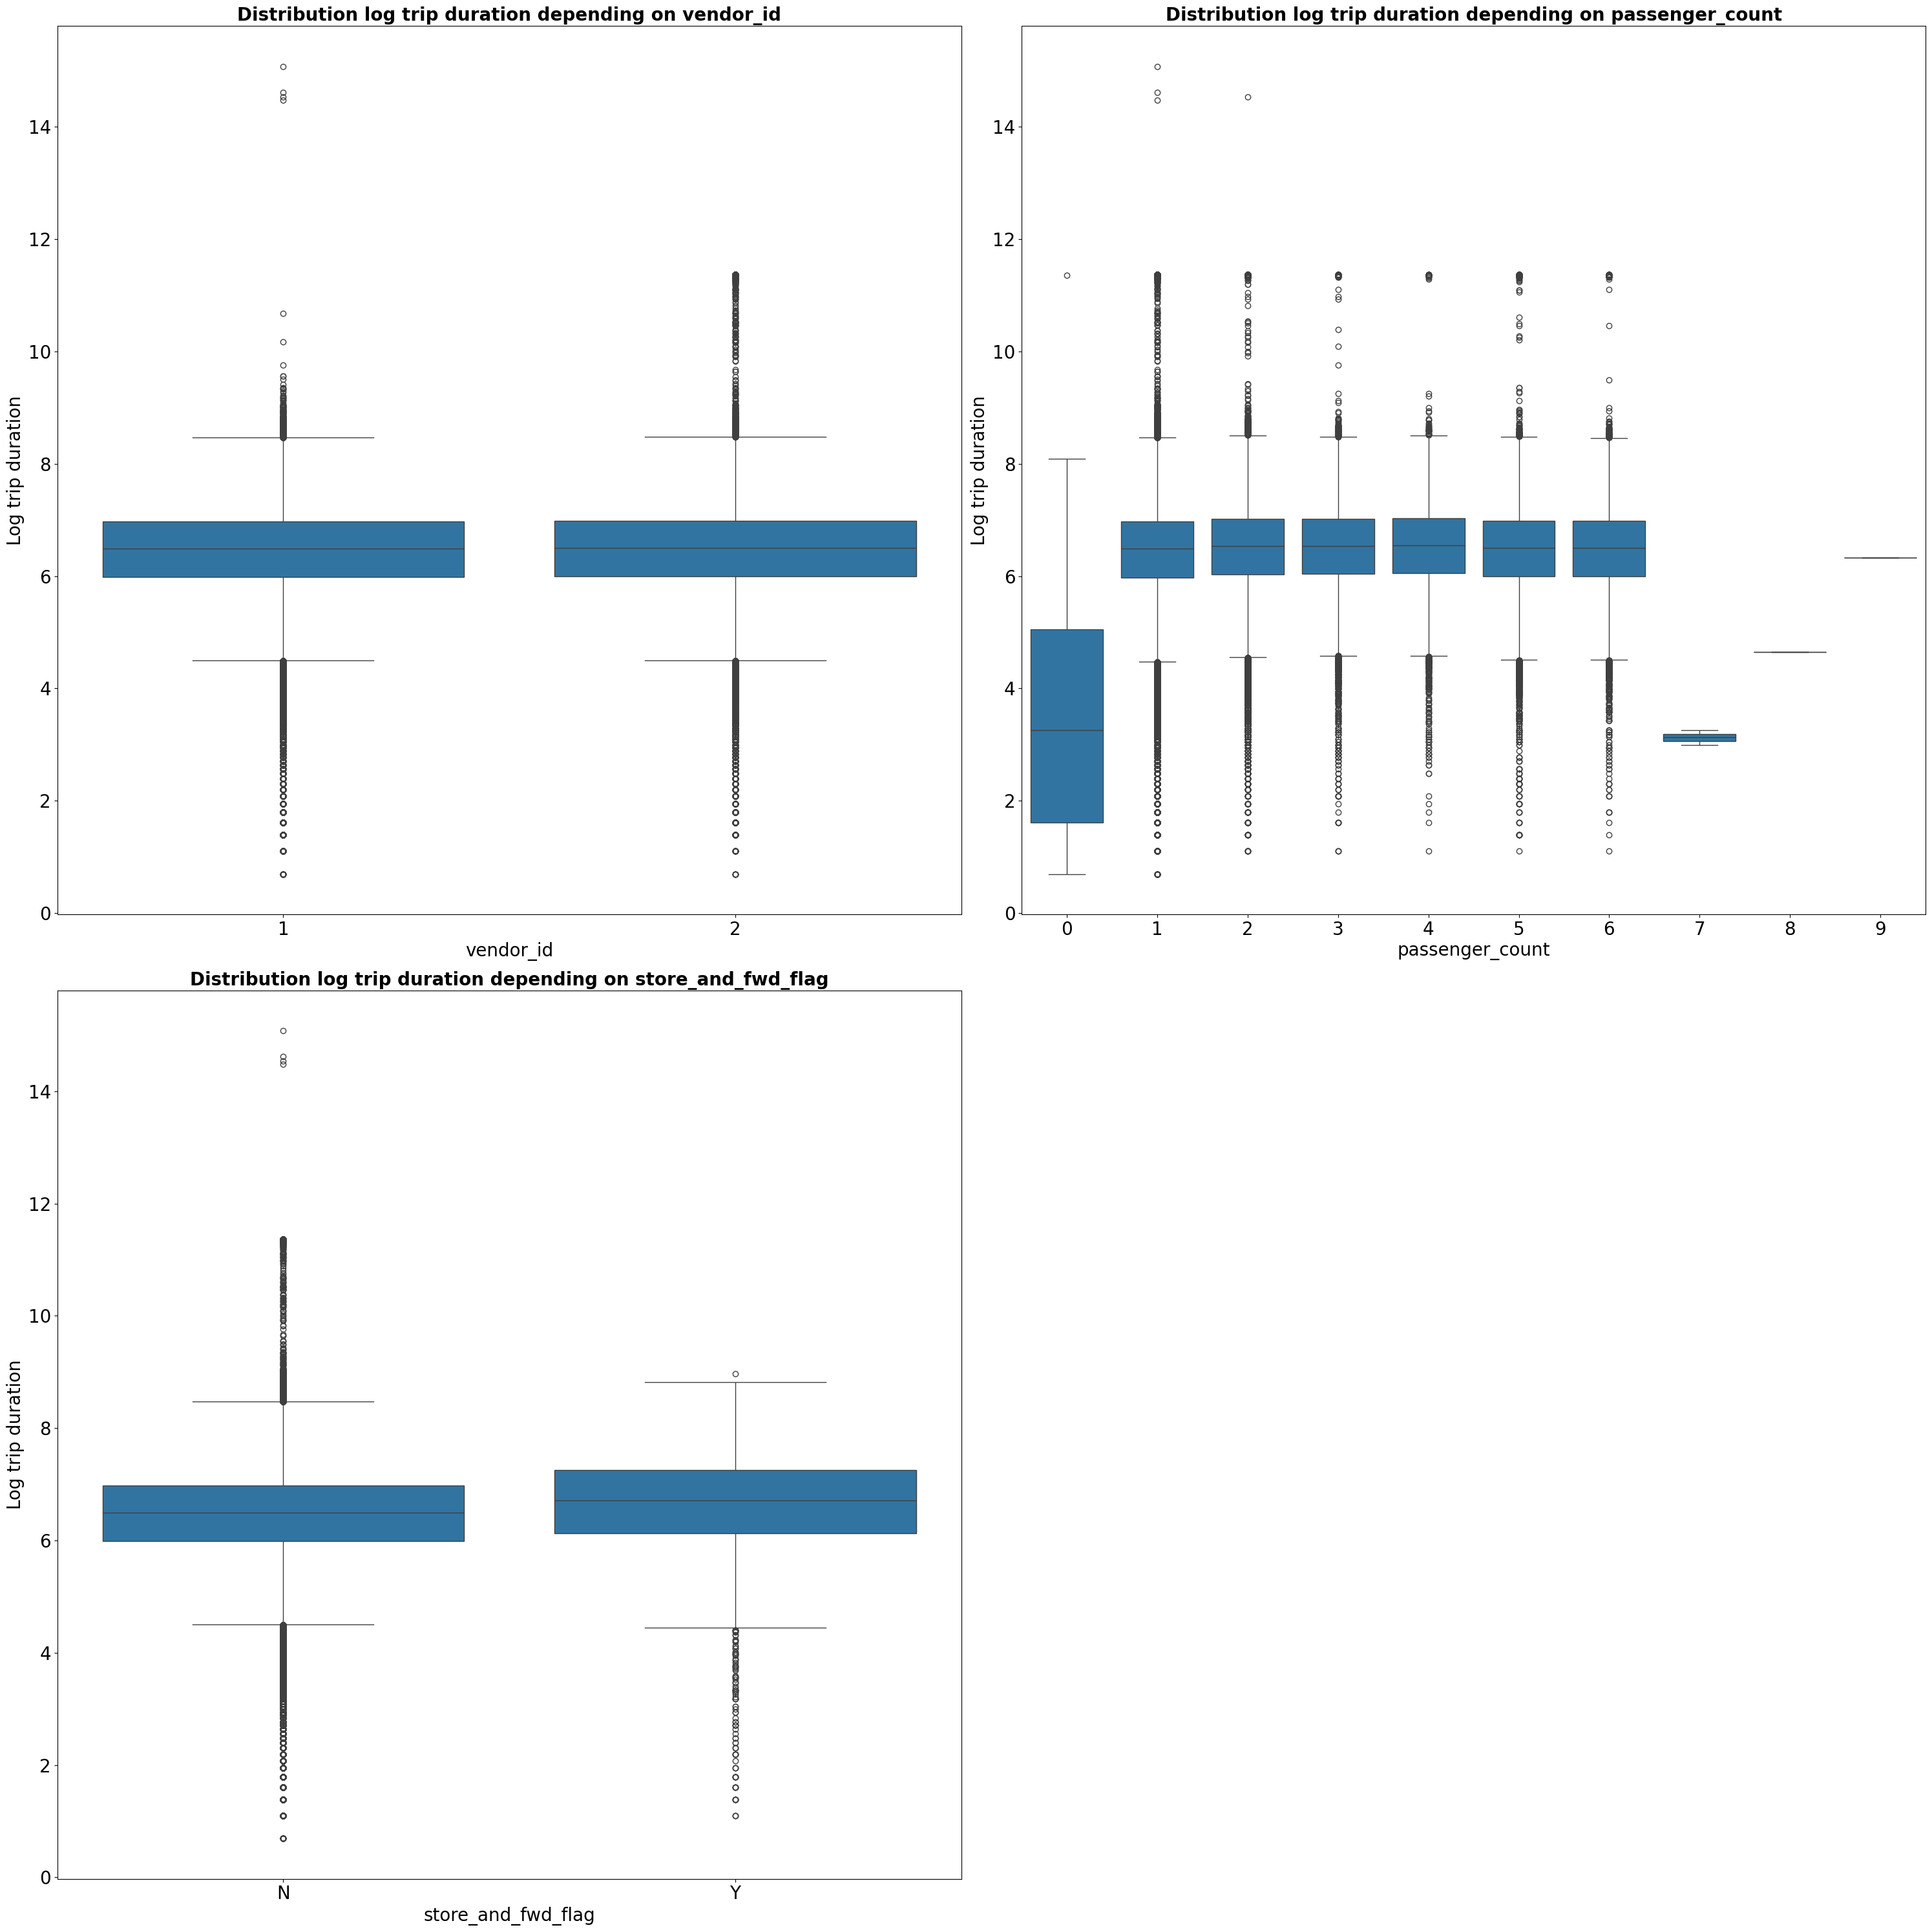

22451

In [ ]:
fig = plt.figure(figsize = (30, 30))
gr = gridspec.GridSpec(2, 2)
features = ['vendor_id', 'passenger_count', 'store_and_fwd_flag']
for feature, grd in zip(features, itertools.product([0, 1, 2], [0, 1])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.boxplot(data=pd.concat([X_train, y_train], axis=1), x=feature, y='log_trip_duration')
    ax.tick_params(labelsize=20)
    ax.set_title(f'Distribution log trip duration depending on {feature}', fontsize = 20, fontweight='heavy')
    ax.set_xlabel(feature, fontsize = 20)
    ax.set_ylabel('Log trip duration', fontsize = 20)
fig.tight_layout()
plt.show()
gc.collect()

Переведите признаки `vendor_id` и `store_and_fwd_flag` в значения $\{0;1\}$

In [ ]:
X_train['vendor_id'] = (X_train['vendor_id'] == 1) * 1
X_train['store_and_fwd_flag'] = (X_train['store_and_fwd_flag'] == 'Y') * 1

X_test['vendor_id'] = (X_test['vendor_id'] == 1) * 1
X_test['store_and_fwd_flag'] = (X_test['store_and_fwd_flag'] == 'Y') * 1
gc.collect()

13

**Вопрос**: Основываясь на графиках выше, как вы думаете, будут ли эти признаки сильными?

**Ответ**: мне кажется нет, так как время в пути, судя по графикам, не зависит от категории признаков (не считая наблюдение, где пассажиров 0, но это что-то странное (возможно, перевозили какую-то вещь от одного человека к другому), но таких наблюдений очень мало)

**Задание 12 (0.25 баллов)**. Проверьте свои предположения, обучив модель в том числе и на этих трех признаках. Обучайте `Ridge`-регрессию со стандартными параметрами. Категориальные признаки закодируйте one-hot-кодированием, а численные отмасштабируйте.

In [ ]:
del count_trip, count_weekday, count_hours, count_month_hour, count_weekday_hour, mean_trip_hour, mean_trip_day, X_train_cat, X_test_cat, X_train_ohe_scaler, X_test_ohe_scaler

In [ ]:
X_train_prep = pd.concat([X_train_prep, X_train[['vendor_id', 'store_and_fwd_flag', 'passenger_count']].reset_index(drop=True)], axis=1)
gc.collect()

0

In [ ]:
X_test_prep = pd.concat([X_test_prep, X_test[['vendor_id', 'store_and_fwd_flag', 'passenger_count']].reset_index(drop=True)], axis=1)
gc.collect()

0

In [ ]:
ridge = Ridge()
ridge.fit(X_train_prep, y_train)
y_train_pred = ridge.predict(X_train_prep)
y_test_pred = ridge.predict(X_test_prep)
print(f'RMSLE on train: {rmsle(y_train, y_train_pred)}')
print(f'RMSLE on test: {rmsle(y_test, y_test_pred)}')

RMSLE on train: 0.47312521273390906
RMSLE on test: 0.47250137551599625


Признаки практически не изменили RMSLE, скорее всего они не значимы для данной модели.

Если признаки не дали какого-то ощутимого улучшения метрики, их можно выбросить из данных.

In [ ]:
X_train_prep.drop(['vendor_id', 'store_and_fwd_flag', 'passenger_count'], axis=1, inplace=True)

## Часть 4. Улучшаем модель (3 балла)

**Задание 13 (1 балл)**. В наших данных есть нетипичные объекты (выбросы, или outliers): с аномально маленьким времени поездки, с очень большим пройденным расстоянием или очень большими остатками регрессии. В этом задании предлагается исключить такие объекты из обучающей выборки. Для этого нарисуйте гистограммы распределения упомянутых выше величин, выберите объекты, которые можно назвать выбросами, и очистите __обучающую выборку__ от них.

Отметим, что хотя эти объекты и выглядят как выбросы, в тестовой выборке тоже скорее всего будут объекты с такими же странными значениями целевой переменной и/или признаков. Поэтому, возможно, чистка обучающей выборки приведёт к ухудшению качества на тесте. Тем не менее, всё равно лучше удалять выбросы из обучения, чтобы модель получалась более разумной и интерпретируемой.

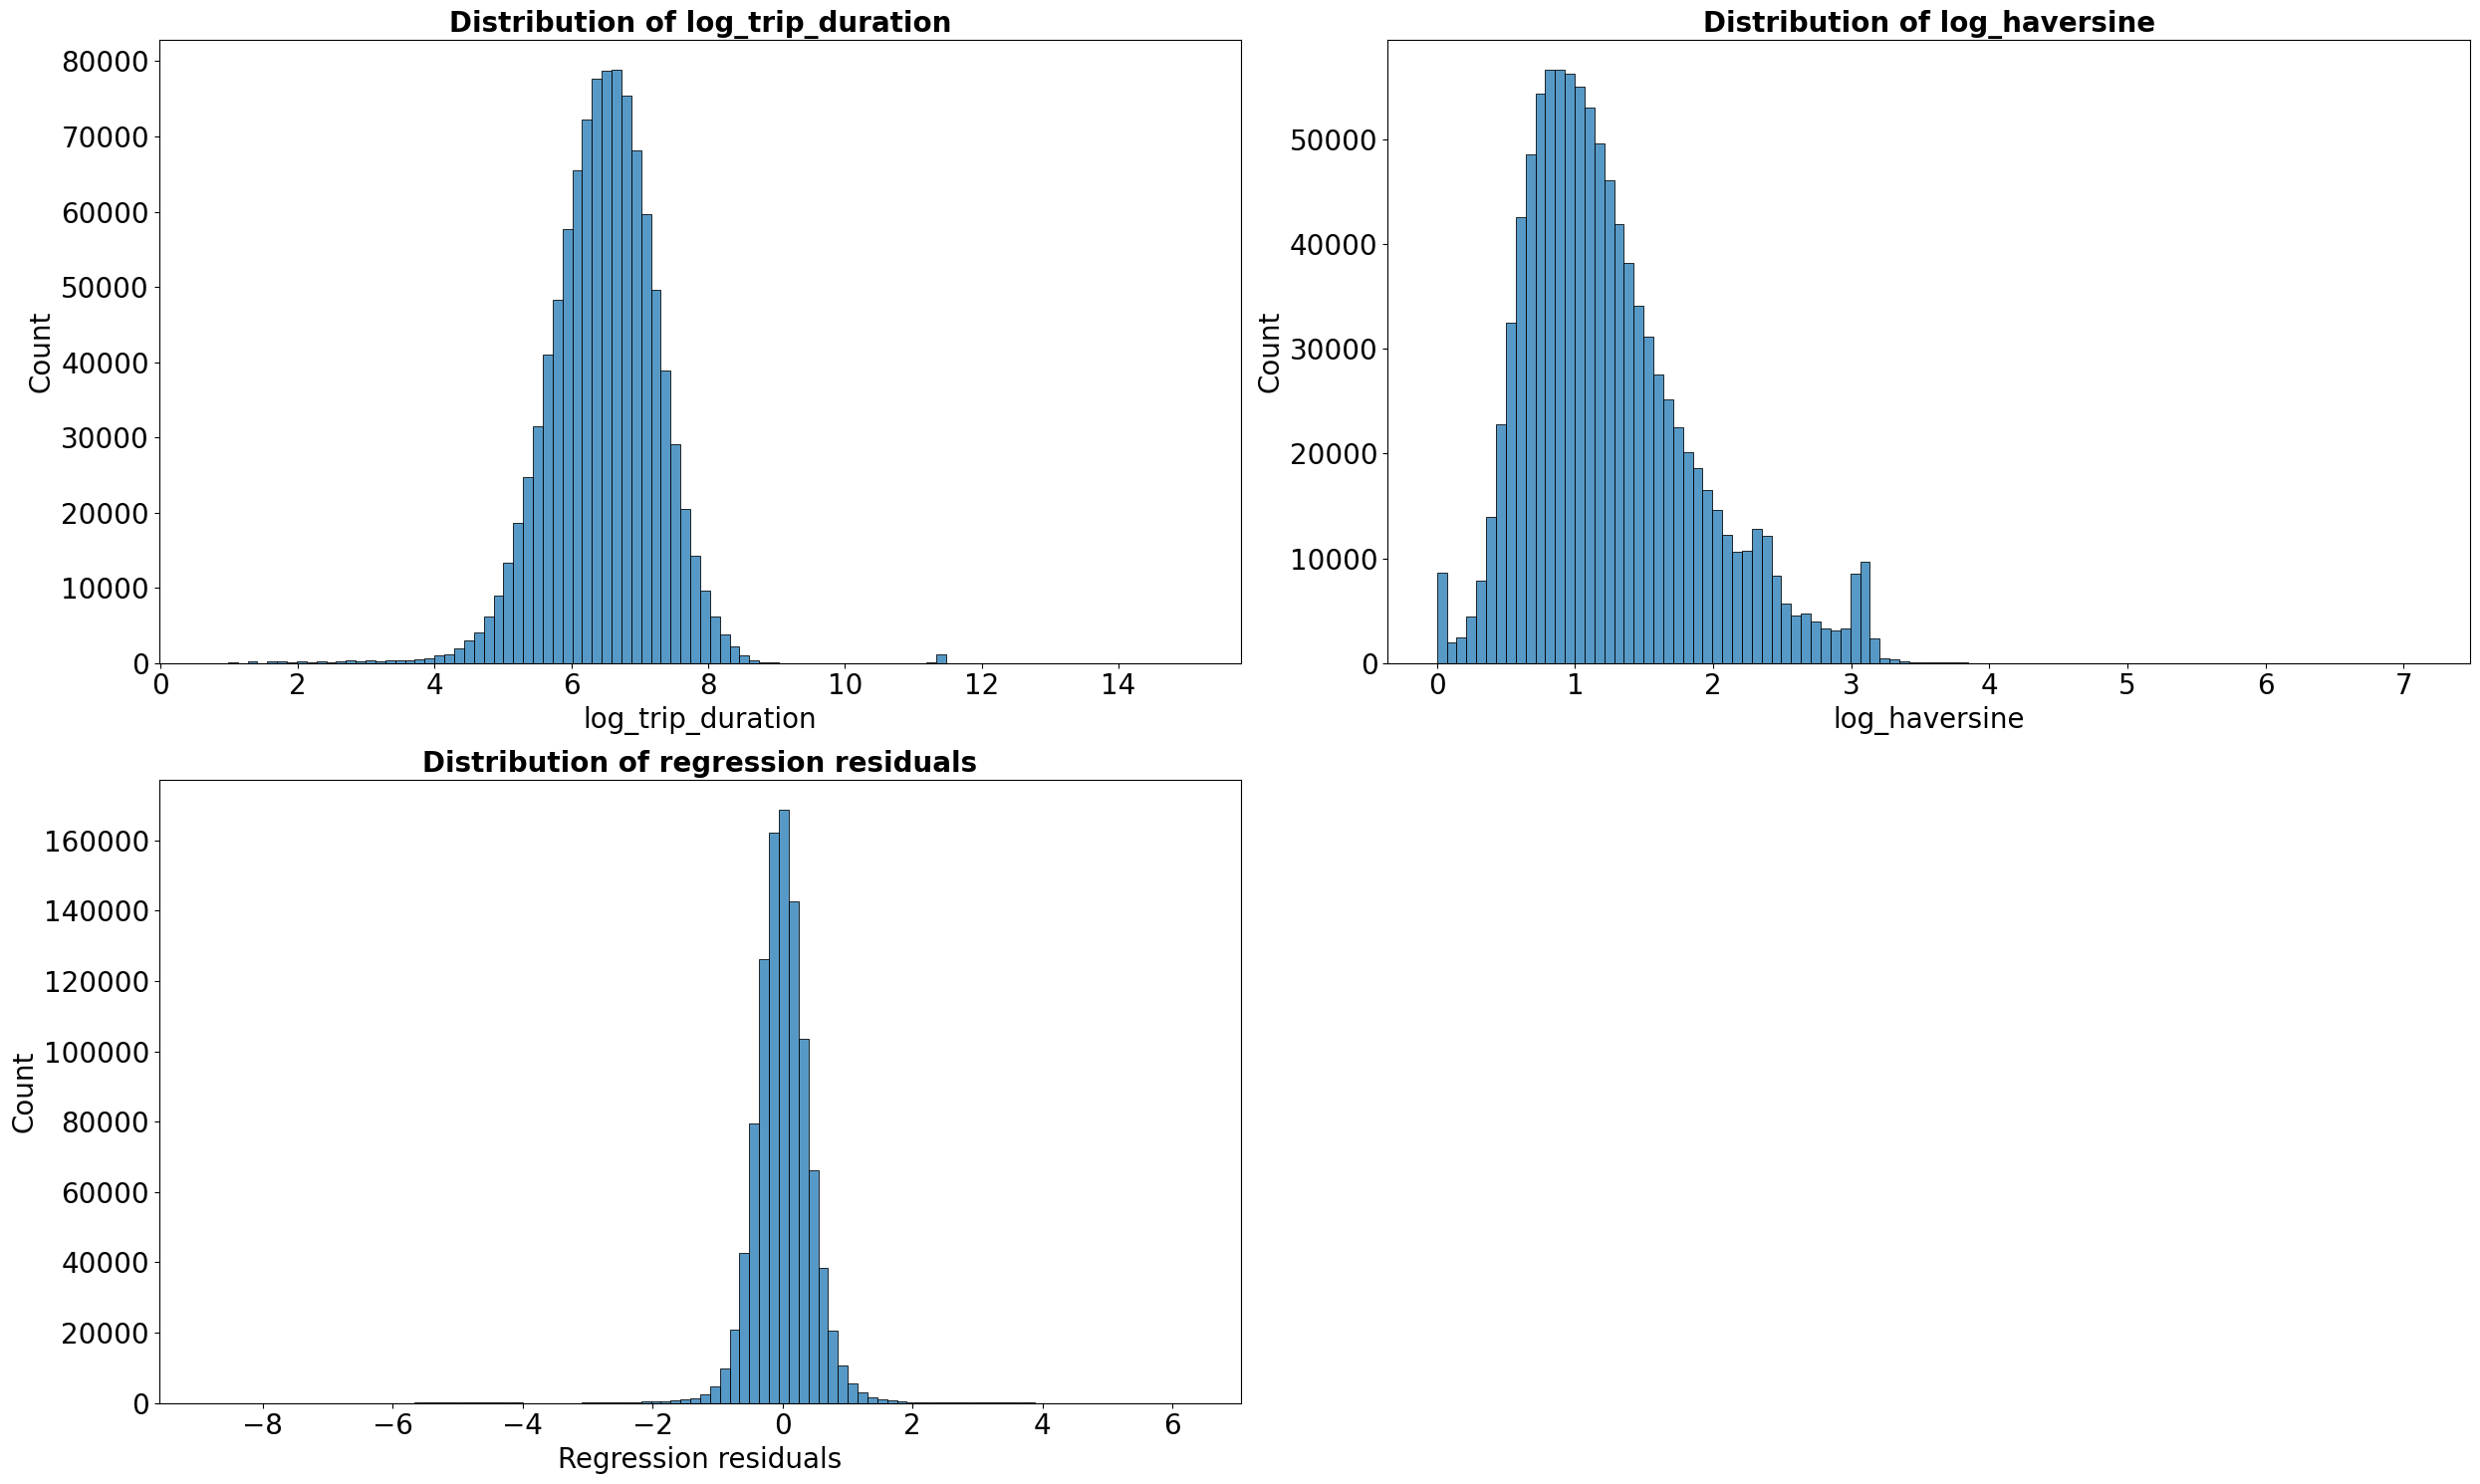

16191

In [ ]:
fig = plt.figure(figsize = (25, 15))
gr = gridspec.GridSpec(2, 2)
features = ['log_trip_duration', 'log_haversine']
for feature, grd in zip(features, itertools.product([0], [0, 1])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.histplot(pd.concat([X_train, y_train], axis=1)[feature], bins=100)
    ax.tick_params(labelsize=20)
    ax.set_title(f'Distribution of {feature}', fontsize = 20, fontweight='heavy')
    ax.set_xlabel(feature, fontsize = 20)
    ax.set_ylabel('Count', fontsize = 20)
ax = plt.subplot(gr[1, 0])
ax = sns.histplot(y_train_pred - y_train, bins=100)
ax.tick_params(labelsize=20)
ax.set_title(f'Distribution of regression residuals', fontsize = 20, fontweight='heavy')
ax.set_xlabel('Regression residuals', fontsize = 20)
ax.set_ylabel('Count', fontsize = 20)
fig.tight_layout()
plt.show()
gc.collect()

In [ ]:
df_train = pd.concat([X_train, y_train], axis=1)

In [ ]:
reg_res = y_train_pred - y_train

In [ ]:
# опять используем межквартильный размах
# регрессионные остатки
q1 = reg_res.quantile(0.25)
q3 = reg_res.quantile(0.75)
iqr = q3 - q1
lim_low = q1 - 1.5 * iqr
lim_up = q3 + 1.5 * iqr
df_train.drop(reg_res[(reg_res > lim_up) | (reg_res < lim_low)].index, inplace=True)

In [ ]:
# время поездки
q1 = df_train['log_trip_duration'].quantile(0.25)
q3 = df_train['log_trip_duration'].quantile(0.75)
iqr = q3 - q1
lim = q1 - 1.5 * iqr
df_train.drop(df_train[df_train['log_trip_duration'] < lim].index, inplace=True)

In [ ]:
# расстояние
q1 = df_train['log_haversine'].quantile(0.25)
q3 = df_train['log_haversine'].quantile(0.75)
iqr = q3 - q1
lim = q3 + 1.5 * iqr
df_train.drop(df_train[df_train['log_haversine'] > lim].index, inplace=True)

Сейчас у нас очень много категориальных признаков. В категориальных признаках могут содержаться редкие категории, обычно это плохо: модель сильно переобучается на таких примерах. Для каждого категориального признака объедините действительно редкие категории в одну, если такие имеются (т.е. если категории действительно редкие).

In [ ]:
df_train.drop(['id', 'vendor_id', 'haversine', 'pickup_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag'], inplace=True, axis=1)

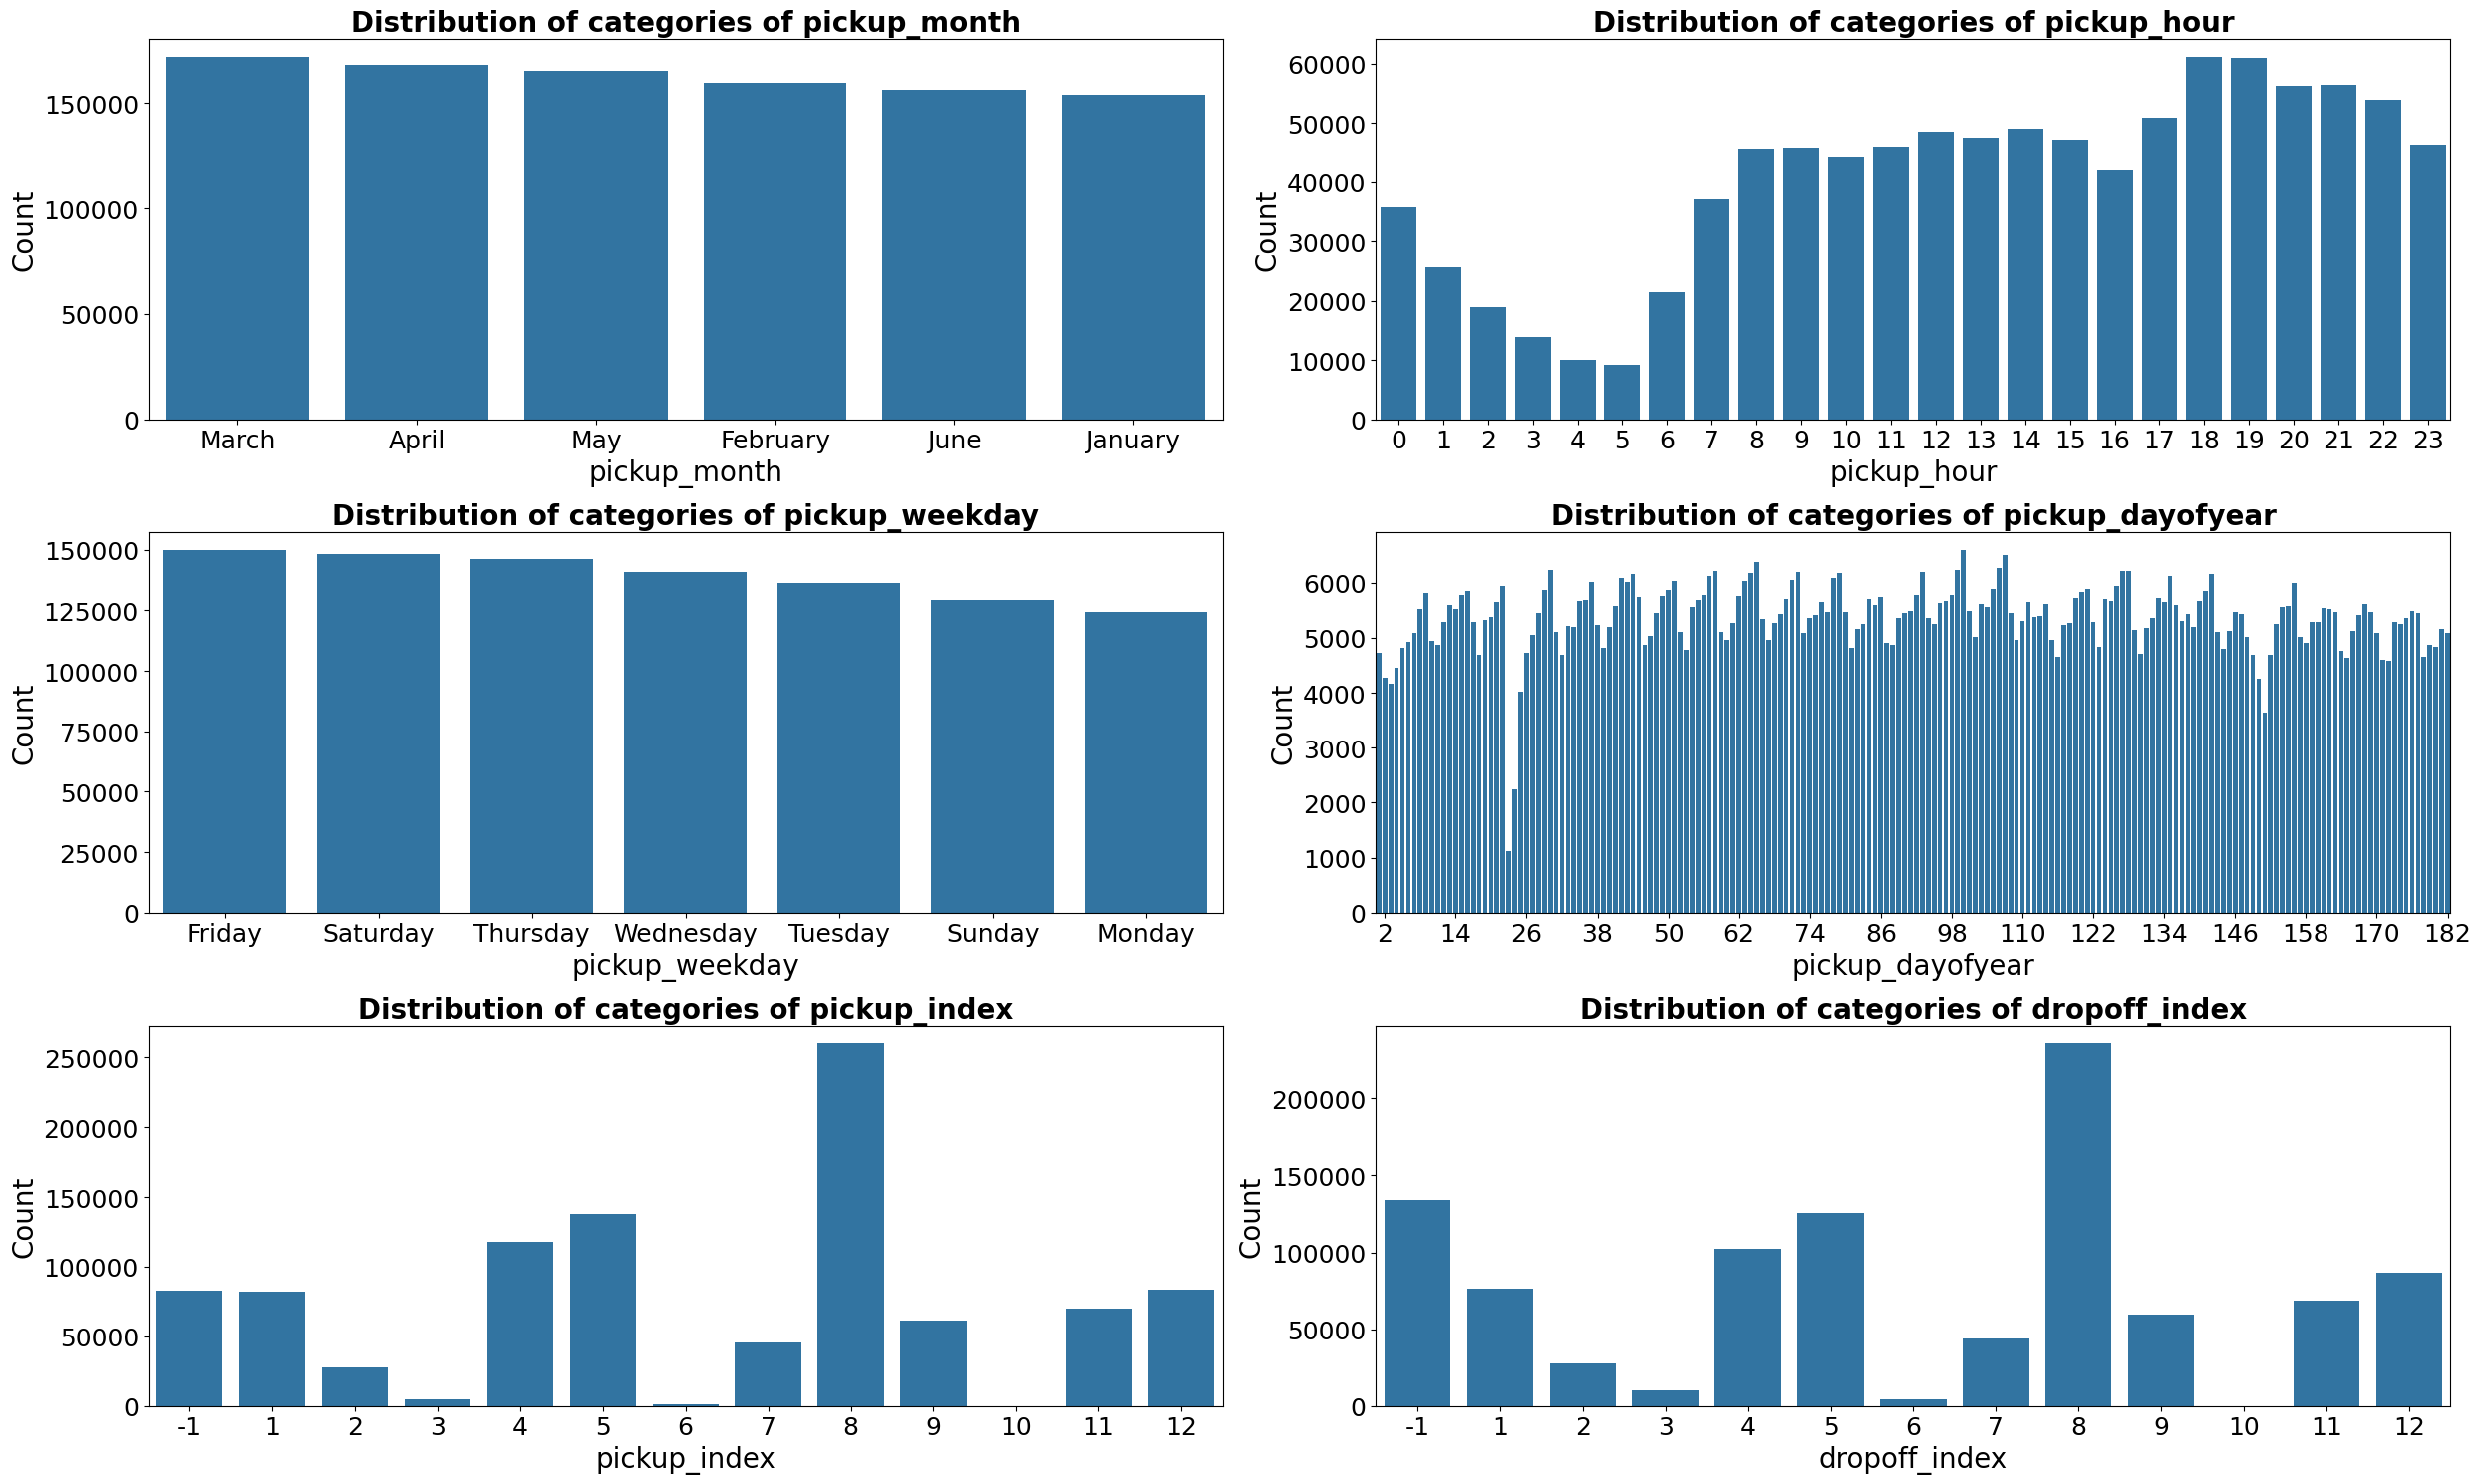

0

In [ ]:
fig = plt.figure(figsize = (25, 15))
gr = gridspec.GridSpec(3, 2)
features = ['pickup_month', 'pickup_hour', 'pickup_weekday', 'pickup_dayofyear', 'pickup_index', 'dropoff_index']
for feature, grd in zip(features, itertools.product([0, 1, 2], [0, 1])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.barplot(df_train[feature].value_counts())
    if feature == 'pickup_dayofyear':
        ax.set_xticks(range(1, 183, 12))
    ax.tick_params(labelsize=18)
    ax.set_title(f'Distribution of categories of {feature}', fontsize = 20, fontweight='heavy')
    ax.set_xlabel(feature, fontsize = 20)
    ax.set_ylabel('Count', fontsize = 20)
fig.tight_layout()
plt.show()
gc.collect()

Здесь редкие категории есть только в признаках индекс места начала и конца поездки, посмотрим на них.

In [ ]:
df_train['pickup_index'].value_counts()

,count
pickup_index,
8,254643
5,135943
4,116367
12,82208
1,80884
-1,80816
11,69027
9,60177
7,44413


Объединим редкую категорию '10' с '11' (так как это рядом лежащие области)

In [ ]:
df_train['pickup_index'] = df_train['pickup_index'].astype('str')

In [ ]:
df_train.loc[(df_train['pickup_index'] == '10') | (df_train['pickup_index'] == '11'), 'pickup_index'] = '10-11'

In [ ]:
df_train['dropoff_index'].value_counts()

,count
dropoff_index,
8,230879
-1,132310
5,123128
4,100371
12,85340
1,75069
11,67647
9,58449
7,42912


Тут такая же ситуация.

In [ ]:
df_train['dropoff_index'] = df_train['dropoff_index'].astype('str')
df_train.loc[(df_train['dropoff_index'] == '10') | (df_train['dropoff_index'] == '11'), 'dropoff_index'] = '10-11'

In [ ]:
X_test['pickup_index'] = X_test['pickup_index'].astype('str')
X_test.loc[(df_train['pickup_index'] == '10') | (X_test['pickup_index'] == '11'), 'pickup_index'] = '10-11'

X_test['dropoff_index'] = X_test['dropoff_index'].astype('str')
X_test.loc[(df_train['dropoff_index'] == '10') | (X_test['dropoff_index'] == '11'), 'dropoff_index'] = '10-11'

Посмотрим на бинарные признаки про аэропорт (другие бинарные признаки никак не связаны между собой).

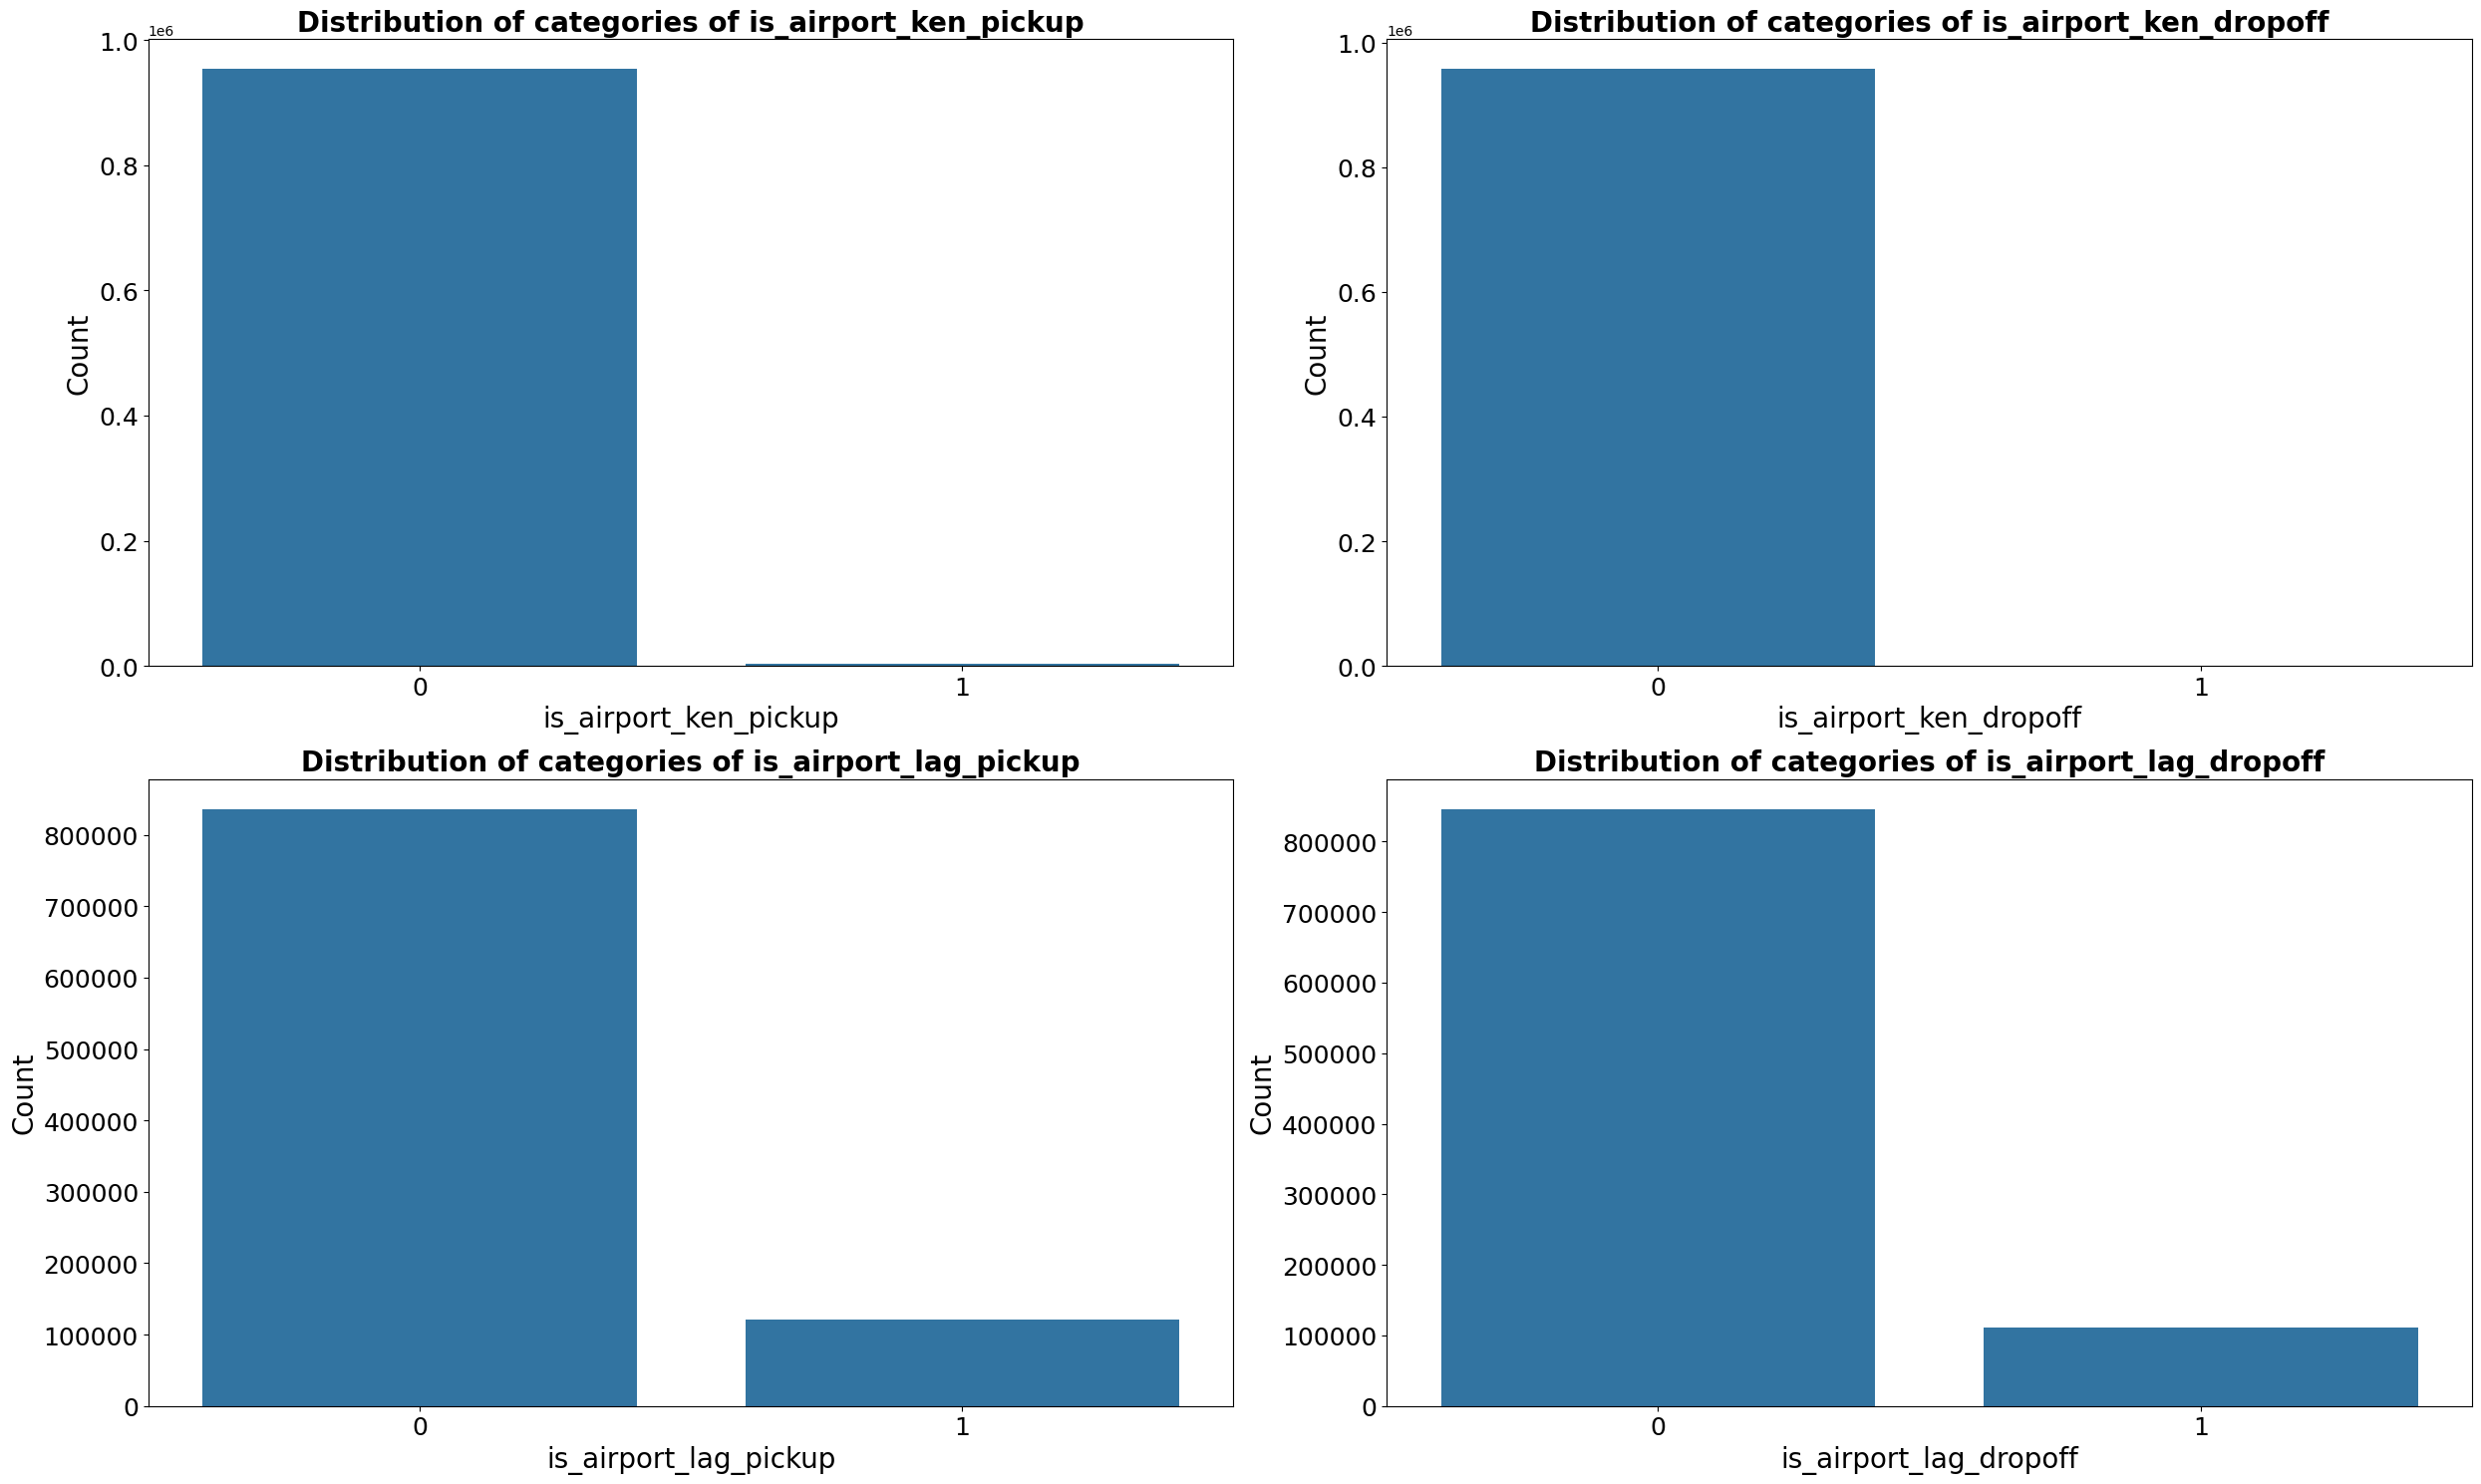

68806

In [ ]:
fig = plt.figure(figsize = (25, 15))
gr = gridspec.GridSpec(2, 2)
features = ['is_airport_ken_pickup', 'is_airport_ken_dropoff', 'is_airport_lag_pickup', 'is_airport_lag_dropoff']
for feature, grd in zip(features, itertools.product([0, 1, ], [0, 1])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.barplot(df_train[feature].value_counts())
    ax.tick_params(labelsize=18)
    ax.set_title(f'Distribution of categories of {feature}', fontsize = 20, fontweight='heavy')
    ax.set_xlabel(feature, fontsize = 20)
    ax.set_ylabel('Count', fontsize = 20)
fig.tight_layout()
plt.show()
gc.collect()

Так как наблюдений, у которых поездка начинается или заканчивается в каждом из аэропортов, не очень много, объединим их.

In [ ]:
df_train['is_airport_pickup'] = ((df_train['is_airport_ken_pickup'] == 1) | (df_train['is_airport_lag_pickup'] == 1)) * 1
X_test['is_airport_pickup'] = ((X_test['is_airport_ken_pickup'] == 1) | (X_test['is_airport_lag_pickup'] == 1)) * 1

Обучите модель на очищенных данных и посчитайте качество на тестовой выборке.

In [ ]:
X_train = df_train.drop('log_trip_duration', axis=1)
y_train = df_train['log_trip_duration']
gc.collect()

0

In [ ]:
categorical = ['pickup_month', 'pickup_hour', 'pickup_weekday', 'pickup_dayofyear', 'pickup_index', 'dropoff_index']
numeric = ['log_haversine']

In [ ]:
column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('scaling', StandardScaler(), numeric)
], verbose_feature_names_out=False)

column_transformer.fit(X_train)
X_train_ohe_scaler = pd.DataFrame(column_transformer.transform(X_train).toarray(), columns=column_transformer.get_feature_names_out())
X_test_ohe_scaler = pd.DataFrame(column_transformer.transform(X_test).toarray(), columns=column_transformer.get_feature_names_out())
gc.collect()

81

In [ ]:
X_train.drop(['is_airport_ken_pickup', 'is_airport_ken_dropoff', 'is_airport_lag_pickup', 'is_airport_lag_dropoff'], axis=1, inplace=True)

In [ ]:
X_train_prep = pd.concat([X_train_ohe_scaler, X_train[['anomaly', 'traffic', 'free_road', 'is_airport_pickup']].reset_index(drop=True)], axis=1)
X_test_prep = pd.concat([X_test_ohe_scaler, X_test[['anomaly', 'traffic', 'free_road', 'is_airport_pickup']].reset_index(drop=True)], axis=1)
gc.collect()

0

In [ ]:
del df_train, reg_res, X_train_ohe_scaler, X_test_ohe_scaler

In [ ]:
gc.collect()

0

In [ ]:
ridge = Ridge()
ridge.fit(X_train_prep, y_train)
y_train_pred = ridge.predict(X_train_prep)
y_test_pred = ridge.predict(X_test_prep)
print(f'RMSLE on train: {rmsle(y_train, y_train_pred)}')
print(f'RMSLE on test: {rmsle(y_test, y_test_pred)}')

RMSLE on train: 0.3551854411836004
RMSLE on test: 0.47961415355771253


**Задание 14 (1 балл)**. После OneHot-кодирования количество признаков в нашем датасете сильно возрастает. Посчитайте колиество признаков до и после кодирования категориальных признаков.

In [ ]:
print(f'Количество признаков до кодирования: {X_train.shape[1]}')
print(f'Количество признаков после кодирования: {X_train_prep.shape[1]}')

Количество признаков до кодирования: 11
Количество признаков после кодирования: 248


Попробуйте обучить не `Ridge`-, а `Lasso`-регрессию. Какой метод лучше?

In [ ]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train_prep, y_train)
y_train_pred = lasso.predict(X_train_prep)
y_test_pred = lasso.predict(X_test_prep)
print(f'RMSLE on train: {rmsle(y_train, y_train_pred)}')
print(f'RMSLE on test: {rmsle(y_test, y_test_pred)}')

RMSLE on train: 0.6651851239743931
RMSLE on test: 0.7952103481780722


С дефолтными значениями регуляризации лучше Ridge.

Разбейте _обучающую выборку_ на обучающую и валидационную в отношении 8:2. По валидационной выборке подберите оптимальные значения параметра регуляризации (по логарифмической сетке) для `Ridge` и `Lasso`, на тестовой выборке измерьте качество лучшей полученной модели.

In [ ]:
del X, y, df

In [ ]:
X_train_prep2, X_val, y_train2, y_val = train_test_split(X_train_prep, y_train, test_size=0.2, random_state=42)
gc.collect()

31

In [ ]:
del m, your_lat_values, your_lon_values, fig, gr

In [ ]:
rmsles = np.array([])
zero_coef = np.array([])
for i in np.logspace(-5, 1, 10):
    lasso = Lasso(i)
    lasso.fit(X_train_prep2, y_train2)
    y_val_pred = lasso.predict(X_val)
    rmsles = np.append(rmsles, rmsle(y_val_pred, y_val))
    zero_coef = np.append(zero_coef, (lasso.coef_ == 0).sum())

In [ ]:
best_lasso = rmsles.min()
best_alpha_lasso = np.argmin(rmsles)
print(f'Меньшая ошибка {best_lasso} со значением alpha = {np.logspace(-4, 1, 10)[best_alpha_lasso]}')
gc.collect()

Меньшая ошибка 0.35564047258586806 со значением alpha = 0.0001


3313

In [ ]:
rmsles = np.array([])
for i in np.logspace(-3, 1, 10):
    ridge = Ridge(i)
    ridge.fit(X_train_prep2, y_train2)
    y_val_pred = ridge.predict(X_val)
    rmsles = np.append(rmsles, rmsle(y_val_pred, y_val))

In [ ]:
best_ridge = rmsles.min()
best_alpha_ridge = np.logspace(-1, 2, 10)[np.argmin(rmsles)]
print(f'Меньшая ошибка {best_ridge} со значением alpha = {best_alpha_ridge}')
gc.collect()

Меньшая ошибка 0.3945901748292299 со значением alpha = 100.0


3178

In [ ]:
ridge = Ridge(best_alpha_ridge)
ridge.fit(X_train_prep, y_train)
y_test_pred = ridge.predict(X_test_prep)
best_rmsle = rmsle(y_test_pred, y_test)

Сохраните наилучшее значение, как бенчмарк на будущее

In [ ]:
best_rmsle

0.4796104643179581

Для каждого перебранного `alpha` для Lasso посчитайте количество нулевых весов в модели и нарисуйте график зависимости его от `alpha`. Как сильно придётся потерять в качестве, если мы хотим с помощью Lasso избавиться хотя бы от половины признаков?

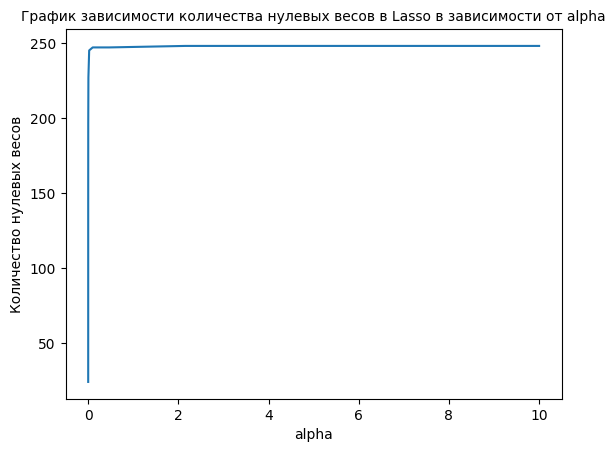

In [ ]:
plt.plot(np.logspace(-5, 1, 10), zero_coef)
plt.title('График зависимости количества нулевых весов в Lasso в зависимости от alpha', fontsize=10)
plt.xlabel('alpha')
plt.ylabel('Количество нулевых весов');

In [ ]:
lasso = Lasso(0.00015)
lasso.fit(X_train_prep, y_train)
y_test_pred = lasso.predict(X_test_prep)
rmsle(y_test_pred, y_test)

0.4806015223849918

In [ ]:
(lasso.coef_ == 0).sum()

125

В данном случае зануляется 125 признаков (на 2 больше половины всех признаков), в сравнении с best_rmsle мы теряем очень немного, менее 0,001

<img src="https://www.dropbox.com/s/wp4jj0599np17lh/map_direction.png?raw=1" width="20%" align="right" style="margin-left: 20px">

**Задание 15 (1 балл)**. Часто бывает полезным использовать взаимодействия признаков (feature interactions), то есть строить новые признаки на основе уже существующих. Выше мы разбили карту Манхэттена на ячейки и придумали признаки "из какой ячейки началась поездка" и "в какой ячейке закончилась поездка".

Давайте попробуем сделать следующее: посчитаем, сколько раз встречается каждая возможная пара этих признаков в нашем датасете и выберем 100 самых частых пар. Закодируем поездки с этими частыми парами как категориальный признак, остальным объектам припишем -1. Получается, что мы закодировали, откуда и куда должно было ехать такси.

**Вопрос**: Почему такой признак потенциально полезный? Почему линейная модель не может самостоятельно "вытащить" эту информацию, ведь у нее в распоряжении есть признаки "из какой ячейки началась поездка" и "в какой ячейке закончилась поездка"?

**Ответ**: некоторые маршруты могут быть более популярными в определенное время суток или в определенные дни недели, что увеличит время в пути, однако линейная регрессия не может уловить этот признак, тк она смотрит, как эти признаки влияют в отдельности, линейно, а комбинация этих признаков - уже нелинейное преобразование.

In [ ]:
common_pairs = X_train.groupby(['pickup_index', 'dropoff_index'],as_index=False)['pickup_month'].count().sort_values(by='pickup_month', ascending=False).iloc[:100, :2]

In [ ]:
pairs = X_train['pickup_index'] + ' ' + X_train['dropoff_index']
common_pairs = common_pairs['pickup_index'] + ' ' + common_pairs['dropoff_index']

In [ ]:
X_train.loc[pairs.isin(common_pairs.values) == False, 'common_pair'] = '-1'

In [ ]:
X_train.loc[pairs.isin(common_pairs.values) == True, 'common_pair'] = pairs

In [ ]:
pairs_test = X_test['pickup_index'] + ' ' + X_test['dropoff_index']
X_test.loc[pairs_test.isin(common_pairs.values) == False, 'common_pair'] = '-1'
X_test.loc[pairs_test.isin(common_pairs.values) == True, 'common_pair'] = pairs_test

In [ ]:
ohe = OneHotEncoder(handle_unknown='ignore')
ohe.fit(pd.DataFrame(X_train['common_pair']))
X_train_cp = pd.DataFrame(ohe.transform(pd.DataFrame(X_train['common_pair'])).toarray(), columns=ohe.get_feature_names_out())
X_test_cp = pd.DataFrame(ohe.transform(pd.DataFrame(X_test['common_pair'])).toarray(), columns=ohe.get_feature_names_out())

In [ ]:
del common_pairs, pairs, pairs_test, X_train_prep2, X_val, y_train2, y_val, X_train, X_test

In [ ]:
X_train_prep = pd.concat([X_train_prep, X_train_cp], axis=1)
X_test_prep = pd.concat([X_test_prep, X_test_cp], axis=1)

In [ ]:
gc.collect()

265

In [ ]:
del y_train_pred, y_test_pred, X_train_cp, X_test_cp

Заново обучите модель (`Ridge`, если она дала более высокое качество в предыдущих экспериментах, и `Lasso` иначе) на новых даннных и посчитайте качество на тестовой выборке

In [ ]:
ridge = Ridge(best_alpha_ridge)
ridge.fit(X_train_prep, y_train)
y_pred_test = ridge.predict(X_test_prep)
print(f'RMSLE on test: {rmsle(y_test, y_pred_test)}')

RMSLE on test: 0.4777104355675542


Ошибка стала поменьше.